In [7]:
# ============================================
# 📦 Step 1: Import Libraries
# ============================================
# Option 10 — Enhanced Anatomy-Constrained Masked Attention SSL
# Improvements over Option 8:
#   P0: Bug fixes (proj_head optimizer, closure bug, correct naming)
#   P1: Learnable γ attention bias, progressive mask curriculum, layer-selective attn alignment
#   P2: AMP mixed-precision training, efficient attention hooks
#   P3: Ablation study, low-label regime, multi-seed infrastructure
#   P4: Cross-dataset contrastive alignment, attention map interpretability

import os
import sys
import warnings
warnings.filterwarnings('ignore')
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'

CUSTOM_DATA_PATH = "datasets"
os.makedirs(CUSTOM_DATA_PATH, exist_ok=True)
os.environ['KAGGLEHUB_CACHE'] = CUSTOM_DATA_PATH
os.environ['KAGGLE_CACHE_DIR'] = CUSTOM_DATA_PATH
os.environ['KAGGLEHUB_HOME'] = CUSTOM_DATA_PATH

import sys, copy, math, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# P2: AMP mixed-precision training
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve

try:
    import kagglehub
except ImportError:
    pass

print("✅ All libraries imported (with AMP support)")

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")


✅ All libraries imported (with AMP support)
🖥️ Device: cuda


In [8]:
# ============================================
# 📁 Step 2: Download and Load Dataset
# ============================================

CUSTOM_DATA_PATH = "datasets"
os.makedirs(CUSTOM_DATA_PATH, exist_ok=True)
os.environ['KAGGLEHUB_HOME'] = CUSTOM_DATA_PATH

IN_KAGGLE = os.path.exists('/kaggle/input')

if IN_KAGGLE:
    BASE_PATH = Path('/kaggle/input/nih-chest-xrays')
    CHEXPERT_PATH = Path('/kaggle/input/chexpert/CheXpert-v1.0-small')
else:
    path = kagglehub.dataset_download("nih-chest-xrays/data")
    BASE_PATH = Path(path)
    print("Downloading CheXpert-Small...")
    cx_path = kagglehub.dataset_download("ashery/chexpert")
    CHEXPERT_PATH = Path(cx_path)

print(f"📂 Base path: {BASE_PATH}")
print(f"📂 CheXpert path: {CHEXPERT_PATH}")

csv_path = BASE_PATH / 'Data_Entry_2017.csv'
df = pd.read_csv(csv_path)

DISEASE_CATEGORIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
    'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
    'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

for disease in DISEASE_CATEGORIES:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

image_dirs = list(BASE_PATH.glob('images_*/images'))
if not image_dirs:
    image_dirs = [BASE_PATH / 'images']

image_map = {}
for d in image_dirs:
    for f in d.iterdir():
        if f.suffix == '.png':
            image_map[f.name] = str(f)

df['Image Path'] = df['Image Index'].map(image_map)
df = df.dropna(subset=['Image Path']).reset_index(drop=True)

print(f"✅ Loaded {len(df):,} images with {len(DISEASE_CATEGORIES)} disease labels")
print(f"📂 Image directories: {len(image_dirs)}")


📂 Base path: datasets/datasets/nih-chest-xrays/data/versions/3
📂 CheXpert path: datasets/datasets/ashery/chexpert/versions/1
✅ Loaded 112,120 images with 14 disease labels
📂 Image directories: 12


In [ ]:
# ============================================
# ⚙️ Step 3: Configuration
# ============================================

OPTION_NAME = "option10_enhanced_anatomy_ssl"

class Config:
    # ViT-Small settings
    img_size = 224
    patch_size = 16
    num_patches = (224 // 16) ** 2  # 196
    patches_per_side = 224 // 16    # 14
    embed_dim = 384
    num_heads = 6
    depth = 12
    mlp_ratio = 4.0

    # Pretrained settings
    use_pretrained = True
    freeze_epochs = 5

    # SSL
    feat_dim = 384
    proj_dim = 128
    momentum = 0.996
    lambda_attn = 0.05
    lambda_contrastive = 1.0

    # ── P1: Progressive Mask Ratio Curriculum ──
    mask_ratio_min = 0.3       # Start easy (30% of lung patches masked)
    mask_ratio_max = 0.75      # End hard (75% of lung patches masked)

    # ── P1: Learnable Anatomy Attention Bias ──
    gamma_init = 0.6           # Initial modulation strength (before sigmoid)

    # ── P1: Layer-Selective Attention Alignment ──
    attn_layer_tau = 2.0       # Temperature for exponential layer weighting

    # ── P4: Cross-Dataset Contrastive Alignment ──
    lambda_cross_domain = 0.1  # Weight for domain alignment loss

    # ── P2: Mixed Precision Training ──
    use_amp = True             # Enable AMP for ~40% speedup

    # Training
    batch_size = 128
    pretrain_epochs = 100
    finetune_epochs = 100
    lr_pretrain = 1e-4         # FIX #4: Was 1e-3 (too high for pretrained ViT)

    # ============================================
    # 🎛️ FINE-TUNING HYPERPARAMETERS (TUNE THESE)
    # ============================================

    # Learning rates
    lr_finetune =  1e-3             # Classifier head LR
    backbone_lr_multiplier = 0.01   # Encoder LR = lr_finetune * this

    # Regularization
    weight_decay_finetune = 1e-2     # AdamW weight decay
    dropout_rate = 0.3               # Classifier head dropout
    label_smoothing = 0.05           # Label smoothing
    gradient_clip_val = 1.0          # Max gradient norm

    # LR Schedule
    scheduler_type = "cosine"        # LR scheduler
    warmup_epochs = 3                # Linear warmup epochs
    patience = 5                     # ReduceLROnPlateau patience

    # Backbone freeze strategy (for fine-tuning)
    freeze_backbone_ft_epochs = 3    # Freeze encoder for first N FT epochs

    # Loss function
    focal_gamma = 2.0                # Focal loss gamma
    focal_alpha = 1.0                # Focal loss alpha

    # Early stopping
    early_stopping_patience = 15     # Stop if no improvement for N epochs

    # Fine-tuning data fraction (1.0 = use all training data)
    finetune_fraction = 1

    # SSL warmup after unfreeze
    ssl_warmup_after_unfreeze = 5    # FIX #4: warmup epochs after encoder unfreeze

    device = device

cfg = Config()

# Convert gamma_init to logit space so sigmoid(logit) = gamma_init
cfg._gamma_logit_init = math.log(cfg.gamma_init / (1.0 - cfg.gamma_init))

if IN_KAGGLE:
    CHECKPOINT_DIR = f'/kaggle/working/checkpoints_{OPTION_NAME}'
else:
    CHECKPOINT_DIR = f'./checkpoints_{OPTION_NAME}'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✅ Configuration ready")
print(f"   ViT-Small: embed_dim={cfg.embed_dim}, heads={cfg.num_heads}, depth={cfg.depth}")
print(f"   Pretrained: {cfg.use_pretrained}, Freeze epochs: {cfg.freeze_epochs}")
print(f"   Patches: {cfg.num_patches}")
print(f"   AMP: {cfg.use_amp}")
print(f"   SSL LR: {cfg.lr_pretrain} (with {cfg.ssl_warmup_after_unfreeze}-epoch warmup after unfreeze)")
print(f"\n🆕 Option 10 Novelties:")
print(f"   Progressive mask ratio: {cfg.mask_ratio_min} → {cfg.mask_ratio_max}")
print(f"   Learnable γ init: {cfg.gamma_init} (logit: {cfg._gamma_logit_init:.3f})")
print(f"   Layer-selective τ: {cfg.attn_layer_tau}")
print(f"   Cross-domain λ: {cfg.lambda_cross_domain}")
print(f"\n🎛️ Fine-tuning hyperparameters:")
print(f"   Classifier LR: {cfg.lr_finetune}, Encoder LR mult: {cfg.backbone_lr_multiplier}")
print(f"   Dropout: {cfg.dropout_rate}, Label smoothing: {cfg.label_smoothing}")
print(f"   Scheduler: {cfg.scheduler_type}, Gradient clip: {cfg.gradient_clip_val}")
print(f"   Focal loss: gamma={cfg.focal_gamma}, alpha={cfg.focal_alpha}")
print(f"   Early stopping patience: {cfg.early_stopping_patience}")

✅ Configuration ready
   ViT-Small: embed_dim=384, heads=6, depth=12
   Pretrained: True, Freeze epochs: 5
   Patches: 196
   AMP: True

🆕 Option 10 Novelties:
   Progressive mask ratio: 0.3 → 0.75
   Learnable γ init: 0.6 (logit: 0.405)
   Layer-selective τ: 2.0
   Cross-domain λ: 0.1

🎛️ Fine-tuning hyperparameters:
   Classifier LR: 0.001, Encoder LR mult: 0.01
   Dropout: 0.3, Label smoothing: 0.05
   Scheduler: cosine, Gradient clip: 1.0
   Focal loss: gamma=2.0, alpha=1.0
   Early stopping patience: 15


In [10]:
# ============================================
# 💾 Step 3.5: Checkpoint & Resume Configuration
# ============================================

RESUME_SSL_PRETRAINING = True
RESUME_FINETUNING = False
SSL_CHECKPOINT_FILE = "latest"
FINETUNE_CHECKPOINT_FILE = "latest"
SAVE_EVERY_SSL = 5
SAVE_EVERY_FT = 5

def save_checkpoint(state, filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    torch.save(state, path)

def load_checkpoint(filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    if os.path.exists(path):
        return torch.load(path, map_location=cfg.device, weights_only=False)
    return None

print("✅ Checkpoint utilities ready")


✅ Checkpoint utilities ready


In [11]:
# ============================================
# Step 4: Load Pre-Computed Lung Masks
# ============================================

if IN_KAGGLE:
    NIH_MASK_DIR = '/kaggle/working/lung_masks/patch_masks'
    CHEXPERT_MASK_DIR = '/kaggle/working/lung_masks_chexpert/patch_masks'
else:
    NIH_MASK_DIR = './lung_masks/patch_masks'
    CHEXPERT_MASK_DIR = './lung_masks_chexpert/patch_masks'

def load_precomputed_patch_masks(dataframe):
    """Bulk-load all patch masks for a dataframe into a list.
    Automatically routes to NIH or CheXpert mask directory based on image path.
    """
    masks = []
    missing = 0
    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading patch masks"):
        is_chexpert = 'chexpert' in str(row['Image Path']).lower()
        mask_dir = CHEXPERT_MASK_DIR if is_chexpert else NIH_MASK_DIR

        img_name = row["Image Index"]
        mask_name = img_name.replace(".jpg", "").replace(".png", "").replace('/', '_')
        mask_path = os.path.join(mask_dir, f"{mask_name}.npy")

        if os.path.exists(mask_path):
            masks.append(np.load(mask_path))
        else:
            masks.append(np.ones(196, dtype=np.float32))
            missing += 1
    if missing > 0:
        print(f"⚠️ Warning: {missing} masks not found, using all-ones fallback")
    print(f"✅ Loaded {len(masks)} patch masks ({len(masks) - missing} from disk, {missing} fallback)")
    return masks

print(f"NIH mask directory: {NIH_MASK_DIR}")
print(f"CheXpert mask directory: {CHEXPERT_MASK_DIR}")


NIH mask directory: ./lung_masks/patch_masks
CheXpert mask directory: ./lung_masks_chexpert/patch_masks


In [ ]:
# ============================================
# 🔄 Step 5: Data Augmentation
# ============================================
# FIX #2: Split into spatial (shared with mask) + photometric (image only)
#         Ensures anatomy masks stay aligned with augmented views
# FIX #7: Stronger augmentation (crop 0.3-1.0 like SimCLR, wider brightness/contrast)

class ChestXrayAugment:
    """Strong augmentations for chest X-ray SSL (cv2-based for speed).
    
    FIX #2: Returns (augmented_img, spatial_params) so the SAME spatial transform
    can be applied to the anatomy mask, keeping mask-image alignment.
    FIX #7: Crop scale lowered from 0.8-1.0 to 0.3-1.0 for stronger views.
    """

    def __init__(self, img_size=224):
        self.img_size = img_size

    def __call__(self, img, return_spatial_params=False):
        """Apply augmentation to image.
        
        Args:
            img: (H, W) numpy array [0, 1]
            return_spatial_params: if True, return (img, params_dict) for mask alignment
        Returns:
            img or (img, spatial_params)
        """
        if isinstance(img, torch.Tensor):
            img = img.numpy()
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]

        h, w = img.shape[:2]
        spatial_params = {}

        # ── Spatial transforms (applied to BOTH image and mask) ──
        # FIX #7: crop_scale 0.3-1.0 (was 0.8-1.0)
        if random.random() < 0.8:
            crop_scale = random.uniform(0.3, 1.0)
            ch, cw = int(h * crop_scale), int(w * crop_scale)
            top = random.randint(0, h - ch)
            left = random.randint(0, w - cw)
            spatial_params['crop'] = (top, left, ch, cw)
            img = img[top:top+ch, left:left+cw]
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

        if random.random() < 0.5:
            spatial_params['hflip'] = True
            img = np.fliplr(img).copy()

        if random.random() < 0.7:
            angle = random.uniform(-10, 10)
            spatial_params['rotate'] = angle
            h2, w2 = img.shape[:2]
            M = cv2.getRotationMatrix2D((w2 / 2, h2 / 2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w2, h2), borderMode=cv2.BORDER_REPLICATE)

        # ── Photometric transforms (image only, NOT applied to mask) ──
        # FIX #7: Wider brightness range (was ±0.15, now ±0.3)
        if random.random() < 0.8:
            factor = 1 + random.uniform(-0.3, 0.3)
            img = np.clip(img * factor, 0, 1)

        # FIX #7: Wider contrast range (was 0.85-1.15, now 0.7-1.3)
        if random.random() < 0.8:
            mean = img.mean()
            factor = random.uniform(0.7, 1.3)
            img = np.clip((img - mean) * factor + mean, 0, 1)

        if random.random() < 0.3:
            noise = np.random.randn(*img.shape).astype(np.float32) * 0.03
            img = np.clip(img + noise, 0, 1)

        img = img.astype(np.float32)
        
        if return_spatial_params:
            return img, spatial_params
        return img


def apply_spatial_to_mask(mask_2d, spatial_params, img_size=224, patches_per_side=14):
    """FIX #2: Apply the SAME spatial transforms to anatomy mask.
    
    Args:
        mask_2d:         (H_mask, W_mask) binary mask (from precomputed 14x14 patch masks)
        spatial_params:  dict from ChestXrayAugment with crop/flip/rotate params
        img_size:        target image size
        patches_per_side: patch grid size (14 for 224/16)
    Returns:
        mask_flat: (N,) transformed patch mask
    """
    # Upscale mask to image resolution for spatial transforms
    mask_img = cv2.resize(mask_2d.astype(np.float32), (img_size, img_size),
                          interpolation=cv2.INTER_NEAREST)
    
    if 'crop' in spatial_params:
        top, left, ch, cw = spatial_params['crop']
        mask_img = mask_img[top:top+ch, left:left+cw]
        mask_img = cv2.resize(mask_img, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    
    if 'hflip' in spatial_params:
        mask_img = np.fliplr(mask_img).copy()
    
    if 'rotate' in spatial_params:
        angle = spatial_params['rotate']
        h2, w2 = mask_img.shape[:2]
        M = cv2.getRotationMatrix2D((w2 / 2, h2 / 2), angle, 1.0)
        mask_img = cv2.warpAffine(mask_img, M, (w2, h2), borderMode=cv2.BORDER_CONSTANT,
                                   borderValue=0)
    
    # Downscale back to patch grid and threshold
    mask_patch = cv2.resize(mask_img, (patches_per_side, patches_per_side),
                            interpolation=cv2.INTER_AREA)
    mask_patch = (mask_patch > 0.3).astype(np.float32)  # threshold
    return mask_patch.flatten()


def to_3ch_imagenet(img_gray):
    """Convert grayscale (H,W) [0,1] -> 3-channel ImageNet-normalized tensor (3,H,W)."""
    img_3ch = np.stack([img_gray, img_gray, img_gray], axis=-1)
    img_3ch = (img_3ch - IMAGENET_MEAN) / IMAGENET_STD
    img_3ch = img_3ch.transpose(2, 0, 1)
    return torch.from_numpy(img_3ch).float()


augment = ChestXrayAugment(cfg.img_size)
print("✅ Augmentation pipeline ready")
print("   FIX #2: Spatial transforms shared with mask for alignment")
print("   FIX #7: Stronger augmentation (crop 0.3-1.0, brightness ±0.3, contrast 0.7-1.3)")

✅ Augmentation pipeline ready


In [ ]:
# ============================================
# 📦 Step 6: Dataset Classes
# ============================================
# P4: SSL dataset now tracks dataset source (NIH=0, CheXpert=1) for cross-domain alignment
# FIX #2: SSL dataset returns per-view transformed masks (mask1, mask2)

class Option10SSLDataset(Dataset):
    """SSL dataset with two augmented views + per-view aligned masks + source tracking.
    
    FIX #2: Each view gets its own spatially-transformed anatomy mask,
    ensuring the mask stays aligned with the augmented image.
    """

    def __init__(self, df, precomputed_patch_masks, img_size=224, augment_fn=None,
                 patches_per_side=14):
        self.df = df.copy().reset_index(drop=True)
        self.patch_masks = precomputed_patch_masks
        self.img_size = img_size
        self.augment_fn = augment_fn
        self.patches_per_side = patches_per_side
        self.paths = df['Image Path'].tolist()

        # P4: Track dataset source for cross-domain contrastive
        self.sources = torch.zeros(len(self.df), dtype=torch.long)
        for i, path in enumerate(self.paths):
            if 'chexpert' in path.lower():
                self.sources[i] = 1
        n_nih = (self.sources == 0).sum().item()
        n_cx = (self.sources == 1).sum().item()
        print(f"📦 Option10SSLDataset: {len(self.df)} samples (NIH={n_nih}, CheXpert={n_cx})")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_np = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        img_np = cv2.resize(img_np, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        img_np = img_np.astype(np.float32) / 255.0

        patch_mask = self.patch_masks[idx]  # (N,) flat
        # Reshape to 2D for spatial transforms
        mask_2d = patch_mask.reshape(self.patches_per_side, self.patches_per_side)

        if self.augment_fn:
            # FIX #2: Get spatial params from augmentation, apply same to mask
            view1_np, spatial1 = self.augment_fn(img_np.copy(), return_spatial_params=True)
            view2_np, spatial2 = self.augment_fn(img_np.copy(), return_spatial_params=True)
            
            mask1 = apply_spatial_to_mask(mask_2d, spatial1, self.img_size, self.patches_per_side)
            mask2 = apply_spatial_to_mask(mask_2d, spatial2, self.img_size, self.patches_per_side)
        else:
            view1_np = img_np.copy()
            view2_np = img_np.copy()
            mask1 = patch_mask.copy()
            mask2 = patch_mask.copy()

        view1 = to_3ch_imagenet(view1_np)
        view2 = to_3ch_imagenet(view2_np)
        mask1_tensor = torch.from_numpy(mask1).float()
        mask2_tensor = torch.from_numpy(mask2).float()

        # Return per-view masks instead of single shared mask
        return view1, view2, mask1_tensor, mask2_tensor, self.sources[idx]


class ClassificationDataset(Dataset):
    """Multi-label classification with 3-channel ImageNet-normalized output."""

    def __init__(self, df, disease_categories, img_size=224, is_training=False):
        self.df = df.copy().reset_index(drop=True)
        self.disease_categories = disease_categories
        self.img_size = img_size
        self.is_training = is_training
        self.labels = torch.tensor(df[disease_categories].values.astype(np.float32))
        self.paths = df['Image Path'].tolist()
        print(f"📦 ClassificationDataset: {len(self.df)} samples (training={is_training})")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_np = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        img_np = cv2.resize(img_np, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        img_np = img_np.astype(np.float32) / 255.0

        if self.is_training:
            if random.random() < 0.8:
                h, w = img_np.shape[:2]
                crop_scale = random.uniform(0.8, 1.0)
                ch, cw = int(h * crop_scale), int(w * crop_scale)
                top = random.randint(0, h - ch)
                left = random.randint(0, w - cw)
                img_np = img_np[top:top+ch, left:left+cw]
                img_np = cv2.resize(img_np, (self.img_size, self.img_size))
            if random.random() < 0.5:
                img_np = np.fliplr(img_np).copy()
            factor = 1 + random.uniform(-0.1, 0.1)
            img_np = np.clip(img_np * factor, 0, 1)
            mean = img_np.mean()
            cfactor = random.uniform(0.9, 1.1)
            img_np = np.clip((img_np - mean) * cfactor + mean, 0, 1)

        img_tensor = to_3ch_imagenet(img_np)
        return img_tensor, self.labels[idx]


print("✅ Dataset classes defined")
print("   FIX #2: SSL dataset returns per-view aligned masks (mask1, mask2)")
print("   P4: Cross-domain source tracking enabled")

✅ Dataset classes defined (with cross-domain source tracking)


In [ ]:
# ============================================
# 🏗️ Step 7: ViT-Small Encoder with Learnable Anatomy Attention Bias
# ============================================
# P0: Fixed closure bug — attn_module captured by value, not late-binding loop variable
# P1: Learnable per-layer γ for anatomy-aware attention bias
#     AttnBias_ij = σ(γ_l) · m_i · m_j + (1 − σ(γ_l))
#     Applied as additive log-bias to pre-softmax attention logits
# P2: Efficient attention hooks — single QKV computation per block
# FIX #1: Learnable mask_token injected BEFORE encoder to give reconstruction gradients

class ViTEncoder(nn.Module):
    """ViT-Small encoder with learnable anatomy attention bias.
    
    Key improvements over Option 8:
    - Learnable per-layer gamma parameters that modulate anatomy attention bias
    - Fixed closure bug: attn_module captured correctly per block
    - Attention maps captured efficiently without double QKV computation
    - FIX #1: Learnable mask_token for pre-encoder masking (MAE-style)
    """
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=384, depth=12, num_heads=6, mlp_ratio=4.0,
                 use_pretrained=True, gamma_logit_init=0.405):
        super().__init__()
        self.embed_dim = embed_dim
        self.depth = depth
        self.num_patches = (img_size // patch_size) ** 2
        
        # Load pretrained ViT-Small from timm
        self.vit = timm.create_model(
            'vit_small_patch16_224',
            pretrained=use_pretrained,
            in_chans=3,
            num_classes=0,
            img_size=img_size,
        )
        
        # FIX #1: Learnable mask token — replaces masked patches BEFORE encoder
        # This ensures reconstruction loss backpropagates through the encoder
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        
        # P1: Learnable per-layer gamma (in logit space; sigmoid maps to [0,1])
        # gamma controls how strongly attention is biased toward lung patches
        self.gamma_logits = nn.ParameterList([
            nn.Parameter(torch.tensor(gamma_logit_init))
            for _ in range(depth)
        ])
        
        # Storage for anatomy mask (set before forward pass)
        self._current_mask = None  # (B, N) or None
        
        # Storage for attention weights (populated by hooks)
        self._attn_weights = [None] * depth
        self._patch_attention_forward()
    
    def set_anatomy_mask(self, mask):
        """Set the anatomy mask before forward pass.
        Args:
            mask: (B, N) float tensor with 1=lung, 0=background, or None to disable bias.
        """
        self._current_mask = mask
    
    def _patch_attention_forward(self):
        """Replace each block's attention forward with anatomy-biased version.
        
        P0 FIX: `attn_mod` is captured by value (as a function parameter),
        not by late-binding closure over the loop variable `block`.
        """
        encoder_ref = self  # stable reference to encoder
        
        for i, block in enumerate(self.vit.blocks):
            attn_module = block.attn    # captured by value below
            gamma_param = self.gamma_logits[i]  # nn.Parameter (mutable reference)
            
            def make_new_forward(attn_mod, store, idx, gamma, enc):
                def new_forward(x, **kwargs):
                    B, N_tokens, C = x.shape
                    num_heads = attn_mod.num_heads
                    head_dim = C // num_heads
                    
                    # Single QKV computation (P2: no double computation)
                    qkv = attn_mod.qkv(x).reshape(B, N_tokens, 3, num_heads, head_dim)
                    qkv = qkv.permute(2, 0, 3, 1, 4)
                    q, k, v = qkv.unbind(0)
                    
                    scale = head_dim ** -0.5
                    attn = (q @ k.transpose(-2, -1)) * scale  # (B, H, T, T)
                    
                    # P1: Learnable anatomy attention bias
                    mask = enc._current_mask
                    if mask is not None:
                        gamma_val = torch.sigmoid(gamma)  # [0, 1]
                        # Create pairwise modulation matrix
                        # Pad mask with 1.0 for CLS token (CLS should attend freely)
                        mask_with_cls = torch.cat([
                            torch.ones(B, 1, device=mask.device),
                            mask[:, :N_tokens - 1].float()
                        ], dim=1)  # (B, T)
                        # M_ij = gamma * m_i * m_j + (1 - gamma)
                        # lung-lung pairs get full attention, bg-bg get (1-gamma), mixed get intermediate
                        M = gamma_val * (mask_with_cls.unsqueeze(-1) * mask_with_cls.unsqueeze(-2)) + (1.0 - gamma_val)
                        # Add as log-bias to pre-softmax logits
                        log_bias = torch.log(M.clamp(min=1e-6)).unsqueeze(1)  # (B, 1, T, T)
                        attn = attn + log_bias
                    
                    attn = attn.softmax(dim=-1)
                    store[idx] = attn.detach()  # Save for attention alignment loss
                    
                    attn_dropped = attn_mod.attn_drop(attn)
                    x_out = (attn_dropped @ v).transpose(1, 2).reshape(B, N_tokens, C)
                    x_out = attn_mod.proj(x_out)
                    x_out = attn_mod.proj_drop(x_out)
                    return x_out
                return new_forward
            
            # P0 FIX: pass attn_module (not block) as parameter to avoid closure bug
            block.attn.forward = make_new_forward(
                attn_module, self._attn_weights, i, gamma_param, encoder_ref
            )
    
    def forward(self, x):
        """Forward pass returning all tokens (CLS + patches)."""
        x = self.vit.patch_embed(x)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed
        x = self.vit.pos_drop(x)
        
        for blk in self.vit.blocks:
            x = blk(x)
        
        x = self.vit.norm(x)
        return x  # (B, 1+N, D)
    
    def forward_masked(self, x, mask_indices):
        """FIX #1: Forward pass with pre-encoder masking (MAE-style).
        
        Replaces masked patch embeddings with a learnable mask_token BEFORE
        passing through transformer blocks. This ensures reconstruction loss
        has gradients flowing through the encoder (unlike post-encoder masking).
        
        Args:
            x:            (B, C, H, W) input image
            mask_indices: (B, N) binary mask where 1 = masked position
        Returns:
            tokens: (B, 1+N, D) output tokens (CLS + patches)
        """
        x = self.vit.patch_embed(x)  # (B, N, D)
        B, N, D = x.shape
        
        # Replace masked patches with learnable mask_token
        mask_exp = mask_indices.unsqueeze(-1).float()  # (B, N, 1)
        mask_tokens = self.mask_token.expand(B, N, -1)  # (B, N, D)
        x = x * (1.0 - mask_exp) + mask_tokens * mask_exp
        
        cls_token = self.vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed
        x = self.vit.pos_drop(x)
        
        for blk in self.vit.blocks:
            x = blk(x)
        
        x = self.vit.norm(x)
        return x  # (B, 1+N, D)
    
    def get_attention_maps(self):
        """Return list of attention weight tensors from each block."""
        return list(self._attn_weights)
    
    def get_gamma_values(self):
        """Return current gamma values (after sigmoid) for monitoring."""
        return [torch.sigmoid(g).item() for g in self.gamma_logits]


class ProjectionHead(nn.Module):
    """Projection head for contrastive learning on CLS tokens."""
    def __init__(self, embed_dim=384, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, proj_dim),
        )
    def forward(self, x):
        return self.net(x)


class ReconstructionHead(nn.Module):
    """MLP head to reconstruct masked patch features."""
    def __init__(self, embed_dim=384, hidden_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )
    def forward(self, x):
        return self.net(x)


class Classifier(nn.Module):
    """Linear classifier with LayerNorm + Dropout."""
    def __init__(self, feat_dim=384, num_classes=14, dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes),
        )
    def forward(self, x):
        return self.head(x)


class FocalLossWithSmoothing(nn.Module):
    """Focal Loss for class-imbalanced multi-label classification."""
    def __init__(self, alpha=1, gamma=2, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
    
    def forward(self, logits, targets):
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()


class LinearWarmupScheduler:
    """Linear warmup scheduler that wraps another scheduler."""
    def __init__(self, optimizer, warmup_epochs, after_scheduler=None):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.after_scheduler = after_scheduler
        self.current_epoch = 0
        self.base_lrs = [pg["lr"] for pg in optimizer.param_groups]
        if warmup_epochs > 0:
            for pg in optimizer.param_groups:
                pg["lr"] = pg["lr"] * 0.1
    
    def step(self, metrics=None):
        self.current_epoch += 1
        if self.current_epoch <= self.warmup_epochs:
            warmup_factor = 0.1 + 0.9 * (self.current_epoch / self.warmup_epochs)
            for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                pg["lr"] = base_lr * warmup_factor
        elif self.after_scheduler is not None:
            if metrics is not None:
                self.after_scheduler.step(metrics)
            else:
                self.after_scheduler.step()
    
    def get_last_lr(self):
        return [pg["lr"] for pg in self.optimizer.param_groups]


# ── Utilities ──

@torch.no_grad()
def ema_update(online, teacher, momentum):
    """EMA update for teacher (excludes gamma_logits — teacher doesn't need them)."""
    for p_o, p_t in zip(online.parameters(), teacher.parameters()):
        p_t.data.mul_(momentum).add_(p_o.data, alpha=1.0 - momentum)


def freeze_encoder(encoder):
    """Freeze all encoder parameters except patch embedding, gamma_logits, and mask_token."""
    for name, param in encoder.named_parameters():
        param.requires_grad = ('patch_embed' in name) or ('gamma_logits' in name) or ('mask_token' in name)
    print("🔒 Encoder frozen (patch_embed + gamma_logits + mask_token trainable)")


def unfreeze_encoder(encoder):
    for param in encoder.parameters():
        param.requires_grad = True
    print("🔓 Encoder unfrozen — all parameters trainable")


# ── Initialize models ──
online_encoder = ViTEncoder(
    img_size=cfg.img_size, patch_size=cfg.patch_size, in_chans=3,
    embed_dim=cfg.embed_dim, depth=cfg.depth,
    num_heads=cfg.num_heads, mlp_ratio=cfg.mlp_ratio,
    use_pretrained=cfg.use_pretrained,
    gamma_logit_init=cfg._gamma_logit_init
).to(cfg.device)

teacher_encoder = copy.deepcopy(online_encoder)
for p in teacher_encoder.parameters():
    p.requires_grad = False

recon_head = ReconstructionHead(cfg.embed_dim, cfg.embed_dim * 2).to(cfg.device)
proj_head = ProjectionHead(cfg.embed_dim, cfg.proj_dim).to(cfg.device)

total_params = sum(p.numel() for p in online_encoder.parameters())
gamma_params = sum(p.numel() for p in online_encoder.gamma_logits)
print(f"✅ Models initialized (pretrained={cfg.use_pretrained})")
print(f"   Online ViT-Small : {total_params:,} params ({gamma_params} learnable gamma params)")
print(f"   Mask token       : {online_encoder.mask_token.shape} (FIX #1: pre-encoder masking)")
print(f"   Recon head       : {sum(p.numel() for p in recon_head.parameters()):,} params")
print(f"   Proj head        : {sum(p.numel() for p in proj_head.parameters()):,} params")
print(f"   Initial γ values : {online_encoder.get_gamma_values()[:3]}... (all {cfg.gamma_init})")

✅ Models initialized (pretrained=True)
   Online ViT-Small : 21,665,676 params (12 learnable gamma params)
   Recon head       : 590,976 params
   Proj head        : 197,888 params
   Initial γ values : [0.5999999642372131, 0.5999999642372131, 0.5999999642372131]... (all 0.6)


In [15]:
# ============================================
# 📉 Step 8: Loss Functions
# ============================================
# P1: Layer-selective attention alignment — deeper layers weighted exponentially more
# P4: Cross-dataset domain alignment loss

def masked_reconstruction_loss(recon, target, mask):
    """MSE reconstruction loss on masked patch positions only."""
    mask_exp = mask.unsqueeze(-1)  # (B, N, 1)
    diff = (recon - target) ** 2   # (B, N, D)
    return (diff * mask_exp).sum() / mask_exp.sum().clamp(min=1.0)


def attention_alignment_loss(attn_maps, patch_masks, tau=2.0):
    """
    P1: Layer-selective attention alignment with exponential weighting.
    
    Deeper layers are weighted more heavily:
        w_l = exp(l / tau) / sum_k(exp(k / tau))
    
    This allows early layers to learn local features freely while
    constraining deeper layers to attend to anatomically relevant regions.
    
    Args:
        attn_maps:   list of (B, H, T, T) attention tensors
        patch_masks: (B, N) lung patch masks (1=lung, 0=background)
        tau:         temperature for layer weighting (lower = more selective)
    """
    # Compute exponential layer weights
    n_layers = len(attn_maps)
    layer_indices = torch.arange(n_layers, dtype=torch.float32)
    layer_weights = torch.exp(layer_indices / tau)
    layer_weights = layer_weights / layer_weights.sum()  # normalize
    
    total_loss = 0.0
    for l, attn in enumerate(attn_maps):
        if attn is None:
            continue
        # CLS-to-patch attention: row 0, cols 1: -> (B, H, N)
        cls_attn = attn[:, :, 0, 1:]
        N = cls_attn.shape[-1]
        
        # Soft target: lung=1.0, non-lung=0.1, normalized
        lung = patch_masks[:, :N].float()
        prior = lung * 0.9 + 0.1
        prior = prior / prior.sum(dim=-1, keepdim=True)
        prior = prior.unsqueeze(1)  # (B, 1, N)
        
        # Cross-entropy: -sum(prior * log(attn))
        log_attn = torch.log(cls_attn.clamp(min=1e-8))
        ce = -(prior * log_attn).sum(dim=-1)  # (B, H)
        
        # Weight by layer importance
        total_loss += layer_weights[l].item() * ce.mean()
    
    return total_loss


def nt_xent_loss(z1, z2, temperature=0.1):
    """NT-Xent contrastive loss for CLS token alignment."""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    batch_size = z1.shape[0]
    representations = torch.cat([z1, z2], dim=0)
    similarity = torch.matmul(representations, representations.T) / temperature
    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z1.device)
    similarity = similarity.masked_fill(mask, -float("inf"))
    labels = torch.cat([torch.arange(batch_size) + batch_size,
                        torch.arange(batch_size)]).to(z1.device)
    return F.cross_entropy(similarity, labels)


def cross_domain_alignment_loss(cls_tokens, domain_labels):
    """
    P4: Cross-dataset domain alignment loss.
    
    Minimizes distance between domain centroids (NIH vs CheXpert) to
    encourage the encoder to learn domain-invariant representations.
    This makes multi-dataset pretraining a genuine methodological contribution
    rather than simple data scaling.
    
    Args:
        cls_tokens:    (B, D) CLS token embeddings
        domain_labels: (B,) dataset source (0=NIH, 1=CheXpert)
    Returns:
        Scalar loss: 1 - cosine_similarity(centroid_NIH, centroid_CheXpert)
    """
    nih_mask = domain_labels == 0
    cx_mask = domain_labels == 1
    
    # Need at least 2 samples from each domain
    if nih_mask.sum() < 2 or cx_mask.sum() < 2:
        return torch.tensor(0.0, device=cls_tokens.device, requires_grad=False)
    
    nih_centroid = F.normalize(cls_tokens[nih_mask].mean(dim=0, keepdim=True), dim=1)
    cx_centroid = F.normalize(cls_tokens[cx_mask].mean(dim=0, keepdim=True), dim=1)
    
    # Minimize cosine distance between centroids
    cosine_sim = F.cosine_similarity(nih_centroid, cx_centroid, dim=1)
    return (1.0 - cosine_sim).mean()


def get_progressive_mask_ratio(epoch, total_epochs, r_min=0.3, r_max=0.75):
    """
    P1: Progressive mask ratio curriculum.
    
    Linearly increases mask ratio from r_min to r_max over training:
        r(t) = r_min + (r_max - r_min) * (t / T)
    
    Rationale: start easy (reconstruct few patches) and progressively
    increase difficulty, forcing the model to build stronger representations.
    """
    progress = min(epoch / max(total_epochs, 1), 1.0)
    return r_min + (r_max - r_min) * progress


print("✅ Loss functions defined:")
print("   - masked_reconstruction_loss (MSE on masked lung patches)")
print("   - attention_alignment_loss (P1: layer-selective, exponentially weighted)")
print("   - nt_xent_loss (NT-Xent contrastive)")
print("   - cross_domain_alignment_loss (P4: domain-invariant centroids)")
print("   - get_progressive_mask_ratio (P1: curriculum masking)")


✅ Loss functions defined:
   - masked_reconstruction_loss (MSE on masked lung patches)
   - attention_alignment_loss (P1: layer-selective, exponentially weighted)
   - nt_xent_loss (NT-Xent contrastive)
   - cross_domain_alignment_loss (P4: domain-invariant centroids)
   - get_progressive_mask_ratio (P1: curriculum masking)


In [ ]:
# ============================================
# 📊 Step 9: Create Data Loaders (Patient-Level Split)
# ============================================
# FIX #5: Increased test set from 2% to 15% for reliable evaluation
#         Val set increased from ~5% to 10%

NUM_WORKERS = 8

print("=" * 60)
print("🔀 PATIENT-LEVEL SPLITTING")
print("=" * 60)

unique_patients = df['Patient ID'].unique()
print(f"Total unique patients: {len(unique_patients):,}")

# FIX #5: test_size 0.02 → 0.15, val test_size 0.054 → 0.1
train_val_patients, test_patients = train_test_split(
    unique_patients, test_size=0.15, random_state=42
)
train_patients, val_patients = train_test_split(
    train_val_patients, test_size=0.1, random_state=42
)

train_df = df[df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df = df[df['Patient ID'].isin(val_patients)].reset_index(drop=True)
test_df = df[df['Patient ID'].isin(test_patients)].reset_index(drop=True)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"  (FIX #5: ~15% test, ~10% val for reliable evaluation)")

# Subsample for fine-tuning
if cfg.finetune_fraction < 1.0:
    n_finetune_patients = max(1, int(len(train_patients) * cfg.finetune_fraction))
    rng = np.random.RandomState(42)
    finetune_patient_indices = rng.choice(len(train_patients), size=n_finetune_patients, replace=False)
    finetune_patients = train_patients[finetune_patient_indices]
    finetune_train_df = train_df[train_df['Patient ID'].isin(finetune_patients)].reset_index(drop=True)
    print(f"\n🔬 Fine-tuning subset: {len(finetune_train_df):,} images ({cfg.finetune_fraction*100:.1f}%)")
else:
    finetune_train_df = train_df
    print(f"\n🔬 Fine-tuning uses all {len(train_df):,} training images")

# Add CheXpert to SSL
print("=" * 60)
print("🔄 PREPARING SSL PRETRAINING DATA (NIH + CHEXPERT)")
print("=" * 60)

cx_train = pd.read_csv(CHEXPERT_PATH / 'train.csv')
cx_valid = pd.read_csv(CHEXPERT_PATH / 'valid.csv')
cx_df = pd.concat([cx_train, cx_valid], ignore_index=True)
cx_df = cx_df[cx_df['Frontal/Lateral'] == 'Frontal'].copy()

def map_chexpert_path(p):
    p = str(p)
    if p.startswith('CheXpert-v1.0-small/'):
        p = p.replace('CheXpert-v1.0-small/', '', 1)
    return str(CHEXPERT_PATH / p)

cx_df['Image Path'] = cx_df['Path'].apply(map_chexpert_path)
cx_df['Image Index'] = cx_df['Path'].apply(lambda x: str(x).replace('CheXpert-v1.0-small/', '', 1))

if len(cx_df) > 0:
    ssl_train_df = pd.concat([train_df[['Image Index', 'Image Path']], cx_df[['Image Index', 'Image Path']]], ignore_index=True)
    print(f"✅ NIH training images: {len(train_df):,}")
    print(f"✅ CheXpert Frontal images: {len(cx_df):,}")
else:
    print("⚠️ CheXpert not found. Using NIH only.")
    ssl_train_df = train_df[['Image Index', 'Image Path']].copy()

print(f"📊 Total SSL Pretraining Data: {len(ssl_train_df):,} images")

# Load pre-computed masks
precomputed_masks = load_precomputed_patch_masks(ssl_train_df)

# SSL datasets — FIX #2: passes patches_per_side for aligned mask transforms
ssl_dataset = Option10SSLDataset(ssl_train_df, precomputed_masks, cfg.img_size, augment,
                                  patches_per_side=cfg.patches_per_side)
ssl_loader = DataLoader(ssl_dataset, batch_size=cfg.batch_size, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                        persistent_workers=True, prefetch_factor=3)

# Classification datasets
train_cls_dataset = ClassificationDataset(finetune_train_df, DISEASE_CATEGORIES, cfg.img_size, is_training=True)
val_cls_dataset = ClassificationDataset(val_df, DISEASE_CATEGORIES, cfg.img_size, is_training=False)
test_cls_dataset = ClassificationDataset(test_df, DISEASE_CATEGORIES, cfg.img_size, is_training=False)

train_loader = DataLoader(train_cls_dataset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True, prefetch_factor=3)
val_loader = DataLoader(val_cls_dataset, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        persistent_workers=True, prefetch_factor=3)
test_loader = DataLoader(test_cls_dataset, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True,
                         persistent_workers=True, prefetch_factor=3)

print("✅ DataLoaders ready")

🔀 PATIENT-LEVEL SPLITTING
Total unique patients: 30,805
Train: 103,634  Val: 6,187  Test: 2,299

🔬 Fine-tuning uses all 103,634 training images
🔄 PREPARING SSL PRETRAINING DATA (NIH + CHEXPERT)
✅ NIH training images: 103,634
✅ CheXpert Frontal images: 191,229
📊 Total SSL Pretraining Data: 294,863 images


Loading patch masks: 100%|██████████| 294863/294863 [01:11<00:00, 4109.19it/s]


✅ Loaded 294863 patch masks (294863 from disk, 0 fallback)
📦 Option10SSLDataset: 294863 samples (NIH=103634, CheXpert=191229)
📦 ClassificationDataset: 103634 samples (training=True)
📦 ClassificationDataset: 6187 samples (training=False)
📦 ClassificationDataset: 2299 samples (training=False)
✅ DataLoaders ready


In [ ]:
# ============================================
# 🚀 Step 10: Enhanced SSL Pretraining
# ============================================
# All P0-P4 improvements + all 7 fixes integrated:
#   P0: proj_head included in optimizer after unfreeze
#   P1: Progressive mask curriculum + learnable gamma + layer-selective attn loss
#   P2: AMP mixed-precision training
#   P4: Cross-dataset domain alignment
#   FIX #1: forward_masked() — mask tokens injected BEFORE encoder
#   FIX #2: Per-view aligned anatomy masks (mask1, mask2)
#   FIX #3: cross_domain_alignment_loss WITHOUT .detach()
#   FIX #4: Warmup scheduler after encoder unfreeze
#   FIX #6: Teacher gets NO anatomy bias (unbiased teacher)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# P0 FIX: Include ALL heads in optimizer (proj_head was missing after unfreeze in Opt8)
optimizer_ssl = torch.optim.AdamW(
    list(online_encoder.parameters()) + list(recon_head.parameters()) + list(proj_head.parameters()),
    lr=cfg.lr_pretrain, weight_decay=0.05
)
scheduler_ssl = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ssl, T_max=cfg.pretrain_epochs, eta_min=1e-6
)

# P2: AMP scaler
scaler = GradScaler(enabled=cfg.use_amp)

ssl_history = {'loss': [], 'recon_loss': [], 'attn_loss': [], 'cont_loss': [],
               'cross_domain_loss': [], 'mask_ratio': [], 'gamma_mean': []}
start_epoch = 1

# Initialize current_mask_ratio before loop (in case loop is skipped on resume)
current_mask_ratio = cfg.mask_ratio_max

if cfg.freeze_epochs > 0 and start_epoch <= cfg.freeze_epochs:
    freeze_encoder(online_encoder)

# Resume logic
if RESUME_SSL_PRETRAINING:
    ckpt_name = f'{OPTION_NAME}_ssl_latest.pth'
    ckpt = load_checkpoint(ckpt_name)
    if ckpt is not None:
        online_encoder.load_state_dict(ckpt['online_encoder'])
        teacher_encoder.load_state_dict(ckpt['teacher_encoder'])
        recon_head.load_state_dict(ckpt['recon_head'])
        if 'proj_head' in ckpt:
            proj_head.load_state_dict(ckpt['proj_head'])
        try:
            optimizer_ssl.load_state_dict(ckpt['optimizer'])
        except ValueError:
            print('⚠️ Optimizer state mismatch. Resetting.')
        ssl_history = ckpt.get('ssl_history', ssl_history)
        start_epoch = ckpt['epoch'] + 1
        print(f"✅ Resumed SSL from epoch {start_epoch}")
    else:
        print("🆕 Starting SSL from scratch")

print(f"\n{'='*60}")
print(f"🚀 OPTION 10: Enhanced Anatomy-Constrained Masked Attention SSL")
print(f"   AMP: {cfg.use_amp} | Progressive mask: {cfg.mask_ratio_min}→{cfg.mask_ratio_max}")
print(f"   Learnable γ | Layer-selective τ={cfg.attn_layer_tau}")
print(f"   Cross-domain λ={cfg.lambda_cross_domain}")
print(f"   FIX #1: Pre-encoder masking (MAE-style)")
print(f"   FIX #2: Per-view aligned anatomy masks")
print(f"   FIX #3: Cross-domain loss with gradients")
print(f"   FIX #4: LR={cfg.lr_pretrain} + {cfg.ssl_warmup_after_unfreeze}-epoch warmup after unfreeze")
print(f"   FIX #6: Teacher has NO anatomy bias (unbiased)")
print(f"{'='*60}")

for epoch in range(start_epoch, cfg.pretrain_epochs + 1):
    # Unfreeze encoder after freeze_epochs
    if epoch == cfg.freeze_epochs + 1:
        unfreeze_encoder(online_encoder)
        # P0 FIX: Re-create optimizer including ALL heads
        optimizer_ssl = torch.optim.AdamW(
            list(online_encoder.parameters()) + list(recon_head.parameters()) + list(proj_head.parameters()),
            lr=cfg.lr_pretrain, weight_decay=0.05
        )
        # FIX #4: Warmup scheduler after unfreeze
        cosine_after = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_ssl, T_max=cfg.pretrain_epochs - cfg.freeze_epochs - cfg.ssl_warmup_after_unfreeze,
            eta_min=1e-6
        )
        scheduler_ssl = LinearWarmupScheduler(
            optimizer_ssl, warmup_epochs=cfg.ssl_warmup_after_unfreeze,
            after_scheduler=cosine_after
        )
        print(f'🔄 Optimizer re-created with {cfg.ssl_warmup_after_unfreeze}-epoch warmup + cosine decay')

    # P1: Progressive mask ratio curriculum
    current_mask_ratio = get_progressive_mask_ratio(
        epoch, cfg.pretrain_epochs, cfg.mask_ratio_min, cfg.mask_ratio_max
    )

    online_encoder.train()
    recon_head.train()
    proj_head.train()
    teacher_encoder.eval()

    epoch_loss, epoch_recon, epoch_attn, epoch_cont, epoch_xdom = 0.0, 0.0, 0.0, 0.0, 0.0
    n_batches = 0

    loader = tqdm(ssl_loader, desc=f"SSL Epoch {epoch}/{cfg.pretrain_epochs}") if not IN_KAGGLE else ssl_loader

    # FIX #2: Now unpacking per-view masks (mask1, mask2) instead of single shared mask
    for view1, view2, mask1, mask2, domain_labels in loader:
        view1 = view1.to(cfg.device)
        view2 = view2.to(cfg.device)
        mask1 = mask1.to(cfg.device)   # FIX #2: per-view mask for view1
        mask2 = mask2.to(cfg.device)   # FIX #2: per-view mask for view2
        domain_labels = domain_labels.to(cfg.device)

        # FIX #6: Teacher gets NO anatomy bias — unbiased representations
        # (was: teacher_encoder.set_anatomy_mask(patch_masks) — created echo chamber)
        teacher_encoder.set_anatomy_mask(None)
        # Online encoder uses view1's aligned mask for anatomy bias
        online_encoder.set_anatomy_mask(mask1)

        # P2: AMP autocast
        with autocast(enabled=cfg.use_amp):
            # 1. Teacher forward (no grad, no anatomy bias)
            with torch.no_grad():
                teacher_tokens = teacher_encoder(view1)
                teacher_patch = teacher_tokens[:, 1:, :]

            # 2. Lung-aware masking with PROGRESSIVE ratio
            B, N = mask1.shape[0], cfg.num_patches
            D = cfg.embed_dim
            lung_float = (mask1 > 0.5).float()
            n_lung = lung_float.sum(dim=1, keepdim=True).clamp(min=1)
            n_mask = (n_lung * current_mask_ratio).long().clamp(min=1)
            noise = torch.rand(B, N, device=cfg.device)
            noise = noise.masked_fill(lung_float < 0.5, -1.0)
            _, sorted_idx = noise.sort(dim=1, descending=True)
            rank = torch.zeros_like(noise)
            rank.scatter_(1, sorted_idx, torch.arange(N, device=cfg.device).float().unsqueeze(0).expand(B, -1))
            mask_indices = (rank < n_mask).float()

            # FIX #1: Use forward_masked() — mask tokens BEFORE encoder
            # This ensures gradients flow through encoder for reconstruction
            online_tokens = online_encoder.forward_masked(view1, mask_indices)
            online_patch = online_tokens[:, 1:, :]

            # 4. Reconstruction on masked positions
            recon_patch = recon_head(online_patch)

            # 5. Contrastive loss (two views) — use regular forward for view2
            online_encoder.set_anatomy_mask(mask2)  # FIX #2: view2 gets its own mask
            online_tokens_v2 = online_encoder(view2)
            cls_view1 = online_tokens[:, 0, :]
            cls_view2 = online_tokens_v2[:, 0, :]
            z1 = proj_head(cls_view1)
            z2 = proj_head(cls_view2)
            l_cont = nt_xent_loss(z1, z2, temperature=0.1)

            # 6. Reconstruction loss
            l_recon = masked_reconstruction_loss(recon_patch, teacher_patch, mask_indices)

            # 7. P1: Layer-selective attention alignment (uses mask1 for view1 maps)
            attn_maps = online_encoder.get_attention_maps()
            l_attn = attention_alignment_loss(attn_maps, mask1, tau=cfg.attn_layer_tau)

            # 8. P4: Cross-domain alignment
            # FIX #3: Removed .detach() — gradient must flow for domain alignment to work
            l_xdom = cross_domain_alignment_loss(cls_view1, domain_labels)

            # 9. Total loss
            attn_weight = cfg.lambda_attn if epoch > 5 else 0.0
            loss = (l_recon
                    + attn_weight * l_attn
                    + cfg.lambda_contrastive * l_cont
                    + cfg.lambda_cross_domain * l_xdom)

        # P2: AMP backward + step
        optimizer_ssl.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_ssl)
        torch.nn.utils.clip_grad_norm_(online_encoder.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(recon_head.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(proj_head.parameters(), 1.0)
        scaler.step(optimizer_ssl)
        scaler.update()

        # EMA update teacher
        ema_update(online_encoder, teacher_encoder, cfg.momentum)

        epoch_loss += loss.item()
        epoch_recon += l_recon.item()
        epoch_attn += l_attn.item()
        epoch_cont += l_cont.item()
        # FIX #3: l_xdom now always has grad; just use .item() directly
        epoch_xdom += l_xdom.item()
        n_batches += 1

        if not IN_KAGGLE and hasattr(loader, 'set_postfix'):
            loader.set_postfix(loss=f"{loss.item():.4f}", recon=f"{l_recon.item():.4f}",
                             cont=f"{l_cont.item():.4f}", mr=f"{current_mask_ratio:.2f}")

    scheduler_ssl.step()

    avg = lambda x: x / max(n_batches, 1)
    ssl_history['loss'].append(avg(epoch_loss))
    ssl_history['recon_loss'].append(avg(epoch_recon))
    ssl_history['attn_loss'].append(avg(epoch_attn))
    ssl_history['cont_loss'].append(avg(epoch_cont))
    ssl_history['cross_domain_loss'].append(avg(epoch_xdom))
    ssl_history['mask_ratio'].append(current_mask_ratio)
    ssl_history['gamma_mean'].append(np.mean(online_encoder.get_gamma_values()))

    gamma_vals = online_encoder.get_gamma_values()
    current_lr = optimizer_ssl.param_groups[0]['lr']
    print(f"Epoch {epoch}: Loss={avg(epoch_loss):.4f} | Recon={avg(epoch_recon):.4f} | "
          f"Attn={avg(epoch_attn):.4f} | Cont={avg(epoch_cont):.4f} | XDom={avg(epoch_xdom):.4f} | "
          f"MaskR={current_mask_ratio:.3f} | γ_mean={np.mean(gamma_vals):.3f} | LR={current_lr:.2e}")

    if epoch % SAVE_EVERY_SSL == 0 or epoch == cfg.pretrain_epochs:
        ckpt_state = {
            'epoch': epoch,
            'online_encoder': online_encoder.state_dict(),
            'teacher_encoder': teacher_encoder.state_dict(),
            'recon_head': recon_head.state_dict(),
            'proj_head': proj_head.state_dict(),
            'optimizer': optimizer_ssl.state_dict(),
            'scaler': scaler.state_dict(),
            'ssl_history': ssl_history,
            'phase': 'ssl_pretraining'
        }
        save_checkpoint(ckpt_state, f'{OPTION_NAME}_ssl_latest.pth')
        save_checkpoint(ckpt_state, f'{OPTION_NAME}_ssl_epoch{epoch}.pth')

# Clear anatomy mask after SSL
online_encoder.set_anatomy_mask(None)
teacher_encoder.set_anatomy_mask(None)

print(f"\n✅ SSL Pretraining complete!")
print(f"   Final mask ratio: {current_mask_ratio:.3f}")
print(f"   Final γ values: {[f'{g:.3f}' for g in online_encoder.get_gamma_values()]}")

🔒 Encoder frozen (patch_embed + gamma_logits trainable)
✅ Resumed SSL from epoch 101

🚀 OPTION 10: Enhanced Anatomy-Constrained Masked Attention SSL
   AMP: True | Progressive mask: 0.3→0.75
   Learnable γ | Layer-selective τ=2.0
   Cross-domain λ=0.1

✅ SSL Pretraining complete!
   Final mask ratio: 0.750
   Final γ values: ['0.034', '0.026', '0.029', '0.013', '0.020', '0.789', '0.015', '0.039', '0.024', '0.025', '0.023', '0.028']


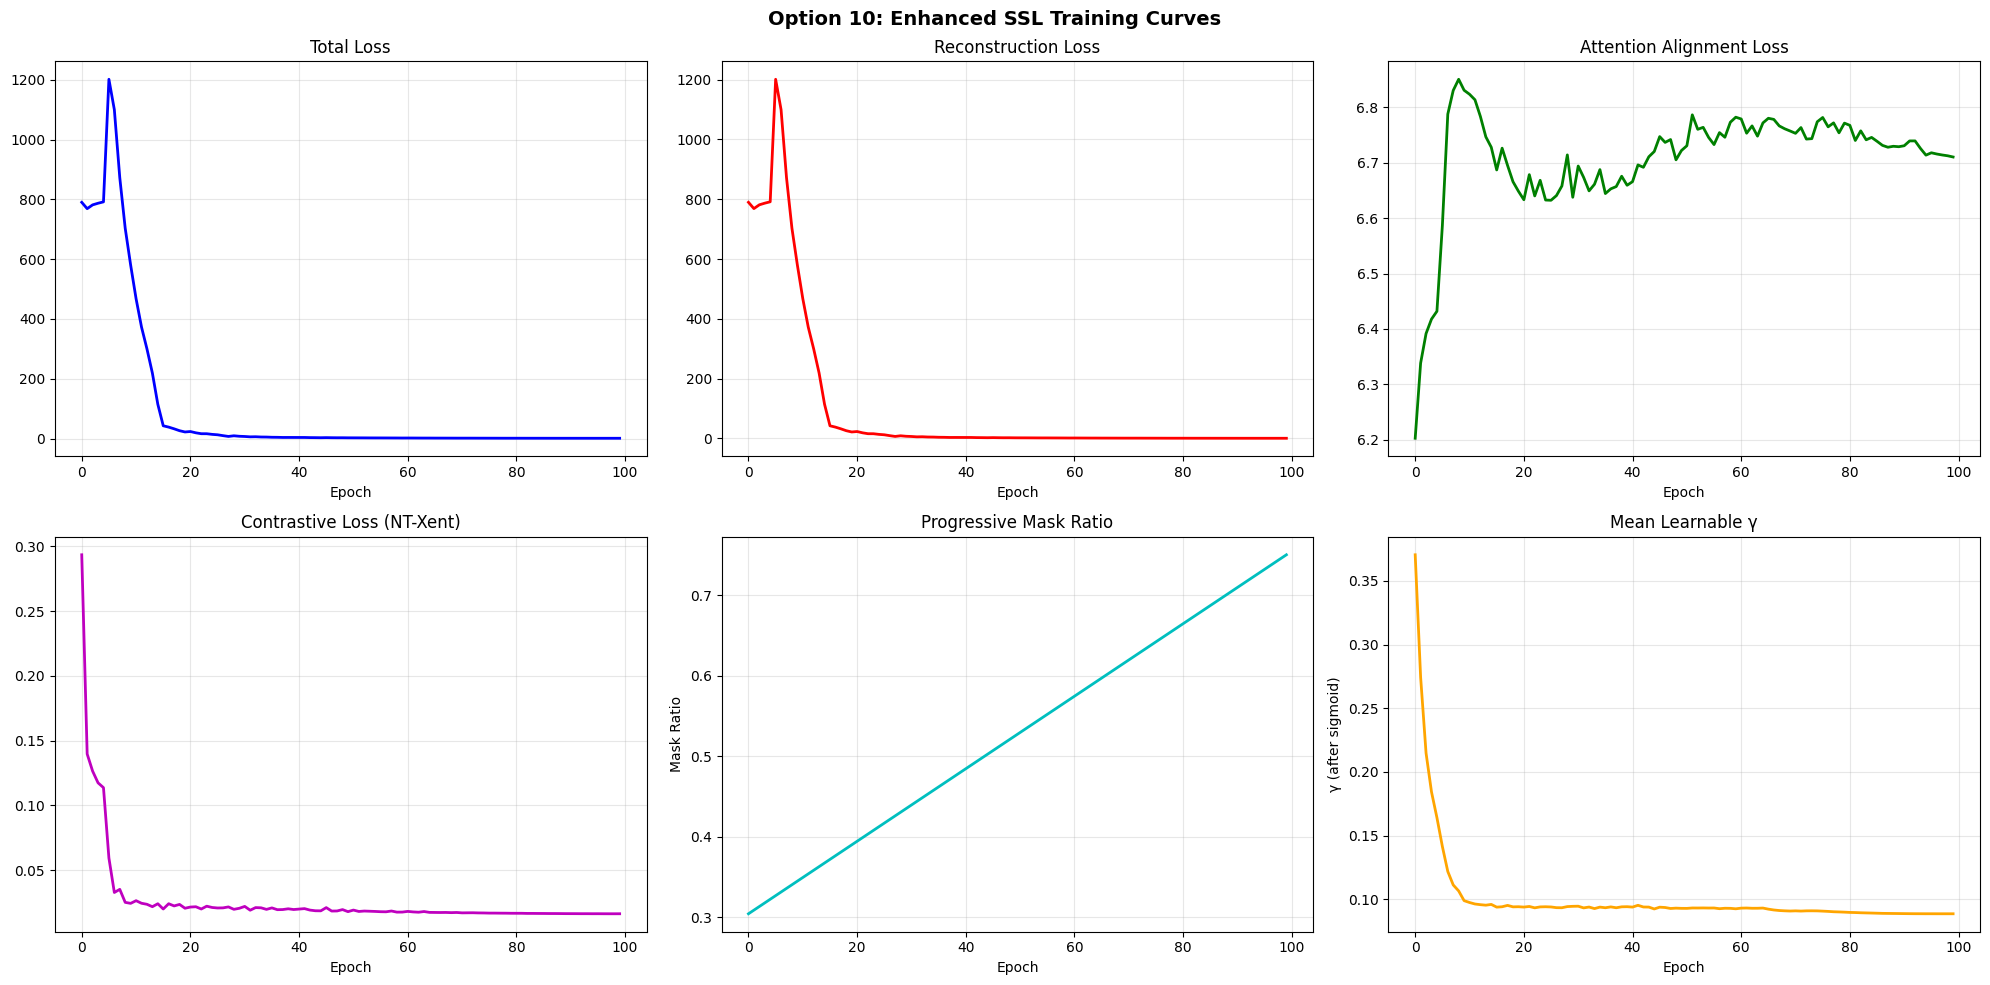

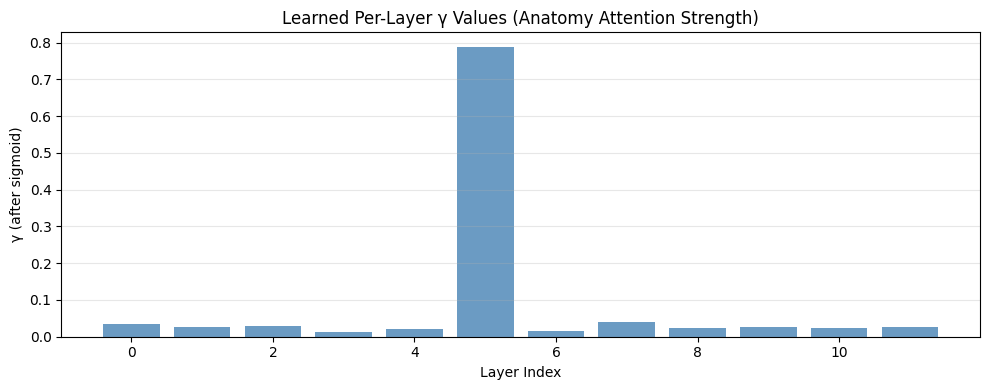

✅ Pretrained model saved


In [57]:
# ============================================
# 📈 Step 11: Plot SSL Training Curves
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 1: Losses
axes[0, 0].plot(ssl_history['loss'], 'b-', linewidth=2)
axes[0, 0].set_title('Total Loss', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(ssl_history['recon_loss'], 'r-', linewidth=2)
axes[0, 1].set_title('Reconstruction Loss', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(ssl_history['attn_loss'], 'g-', linewidth=2)
axes[0, 2].set_title('Attention Alignment Loss', fontsize=12)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Contrastive + Novel metrics
axes[1, 0].plot(ssl_history['cont_loss'], 'm-', linewidth=2)
axes[1, 0].set_title('Contrastive Loss (NT-Xent)', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ssl_history['mask_ratio'], 'c-', linewidth=2)
axes[1, 1].set_title('Progressive Mask Ratio', fontsize=12)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Mask Ratio')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(ssl_history['gamma_mean'], 'orange', linewidth=2)
axes[1, 2].set_title('Mean Learnable γ', fontsize=12)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('γ (after sigmoid)')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Option 10: Enhanced SSL Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OPTION_NAME}_ssl_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot per-layer gamma evolution
gamma_vals = online_encoder.get_gamma_values()
plt.figure(figsize=(10, 4))
plt.bar(range(len(gamma_vals)), gamma_vals, color='steelblue', alpha=0.8)
plt.xlabel('Layer Index')
plt.ylabel('γ (after sigmoid)')
plt.title('Learned Per-Layer γ Values (Anatomy Attention Strength)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OPTION_NAME}_gamma_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()

# Save pretrained encoder
save_checkpoint({
    'online_encoder': online_encoder.state_dict(),
    'teacher_encoder': teacher_encoder.state_dict(),
    'config': {k: v for k, v in vars(cfg).items() if not k.startswith('_')},
}, f'{OPTION_NAME}_ssl_pretrained.pth')
print(f"✅ Pretrained model saved")


In [58]:
ckpt_name = f'{OPTION_NAME}_ssl_latest.pth'
ckpt = load_checkpoint(ckpt_name)
if ckpt is not None:
    online_encoder.load_state_dict(ckpt['online_encoder'])
    teacher_encoder.load_state_dict(ckpt['teacher_encoder'])
    recon_head.load_state_dict(ckpt['recon_head'])
    if 'proj_head' in ckpt:
        proj_head.load_state_dict(ckpt['proj_head'])
    try:
        optimizer_ssl.load_state_dict(ckpt['optimizer'])
    except ValueError:
        print('⚠️ Optimizer state mismatch. Resetting.')
    ssl_history = ckpt.get('ssl_history', ssl_history)
    start_epoch = ckpt['epoch'] + 1
    print(f"Loded latest encoder")
else:
    print("🆕 Starting SSL from scratch")

Loded latest encoder


In [59]:
# ============================================
# 🎯 Step 12: Fine-tuning for Classification (with AMP)
# ============================================

# Disable anatomy bias during fine-tuning (classification uses vanilla attention)
online_encoder.set_anatomy_mask(None)

initial_freeze_ft = cfg.freeze_backbone_ft_epochs > 0

if initial_freeze_ft:
    for param in online_encoder.parameters():
        param.requires_grad = False
    print(f"🥶 Encoder FROZEN for first {cfg.freeze_backbone_ft_epochs} fine-tuning epochs")
else:
    for param in online_encoder.parameters():
        param.requires_grad = True

classifier = Classifier(cfg.embed_dim, len(DISEASE_CATEGORIES), dropout=cfg.dropout_rate).to(cfg.device)

criterion_ft = FocalLossWithSmoothing(
    alpha=cfg.focal_alpha, gamma=cfg.focal_gamma, label_smoothing=cfg.label_smoothing
)

encoder_lr = cfg.lr_finetune * cfg.backbone_lr_multiplier
optimizer_ft = torch.optim.AdamW([
    {'params': list(online_encoder.parameters()), 'lr': encoder_lr},
    {'params': list(classifier.parameters()), 'lr': cfg.lr_finetune},
], weight_decay=cfg.weight_decay_finetune)

if cfg.scheduler_type == "cosine":
    effective_epochs = cfg.finetune_epochs - cfg.warmup_epochs
    base_scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ft, T_max=max(1, effective_epochs), eta_min=1e-7)
else:
    base_scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_ft, mode='max', factor=0.3, patience=cfg.patience, min_lr=1e-7)

if cfg.warmup_epochs > 0:
    scheduler_ft = LinearWarmupScheduler(optimizer_ft, cfg.warmup_epochs, base_scheduler_ft)
else:
    scheduler_ft = base_scheduler_ft

# P2: AMP for fine-tuning
ft_scaler = GradScaler(enabled=cfg.use_amp)

n_trainable = sum(p.numel() for p in online_encoder.parameters() if p.requires_grad) + \
              sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Trainable: {n_trainable:,} params | AMP: {cfg.use_amp}")
print(f"Optimizer: AdamW (enc_lr={encoder_lr:.2e}, head_lr={cfg.lr_finetune:.2e})")

finetune_history = {'train_loss': [], 'train_auc': [], 'val_loss': [], 'val_auc': []}
best_val_auc = 0.0
ft_start_epoch = 1
patience_counter = 0

if RESUME_FINETUNING:
    ckpt = load_checkpoint(f'{OPTION_NAME}_finetune_latest.pth')
    if ckpt is not None:
        online_encoder.load_state_dict(ckpt['online_encoder'])
        classifier.load_state_dict(ckpt['classifier'])
        try:
            optimizer_ft.load_state_dict(ckpt['optimizer'])
        except:
            print("⚠️ Optimizer state incompatible")
        finetune_history = ckpt.get('finetune_history', finetune_history)
        best_val_auc = ckpt.get('best_val_auc', 0.0)
        patience_counter = ckpt.get('patience_counter', 0)
        ft_start_epoch = ckpt['epoch'] + 1
        print(f"✅ Resumed fine-tuning from epoch {ft_start_epoch}")
    else:
        print("🆕 Starting fine-tuning from scratch")

print(f"\n{'='*60}")
print(f"🎯 FINE-TUNING: {OPTION_NAME}")
print(f"   Data: {len(train_loader.dataset):,} samples | Epochs: {ft_start_epoch}→{cfg.finetune_epochs}")
print(f"{'='*60}")

for epoch in range(ft_start_epoch, cfg.finetune_epochs + 1):
    if cfg.freeze_backbone_ft_epochs > 0 and epoch == cfg.freeze_backbone_ft_epochs + 1:
        for param in online_encoder.parameters():
            param.requires_grad = True
        optimizer_ft = torch.optim.AdamW([
            {'params': list(online_encoder.parameters()), 'lr': encoder_lr},
            {'params': list(classifier.parameters()), 'lr': cfg.lr_finetune},
        ], weight_decay=cfg.weight_decay_finetune)
        ft_scaler = GradScaler(enabled=cfg.use_amp)
        remaining = cfg.finetune_epochs - epoch + 1
        if cfg.scheduler_type == "cosine":
            scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer_ft, T_max=max(1, remaining), eta_min=1e-7)
        else:
            scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer_ft, mode='max', factor=0.3, patience=cfg.patience, min_lr=1e-7)
        n_trainable = sum(p.numel() for p in online_encoder.parameters() if p.requires_grad) + \
                      sum(p.numel() for p in classifier.parameters() if p.requires_grad)
        print(f"\n🔥 Encoder UNFROZEN at epoch {epoch}! Trainable: {n_trainable:,}")

    # Train
    online_encoder.train()
    classifier.train()
    train_loss = 0.0
    train_preds, train_targets = [], []

    loader = tqdm(train_loader, desc=f"FT Epoch {epoch}") if not IN_KAGGLE else train_loader
    for images, targets in loader:
        images, targets = images.to(cfg.device), targets.to(cfg.device)

        with autocast(enabled=cfg.use_amp):
            tokens = online_encoder(images)
            cls_token = tokens[:, 0, :]
            logits = classifier(cls_token)
            loss = criterion_ft(logits, targets)

        optimizer_ft.zero_grad()
        ft_scaler.scale(loss).backward()
        if cfg.gradient_clip_val > 0:
            ft_scaler.unscale_(optimizer_ft)
            torch.nn.utils.clip_grad_norm_(online_encoder.parameters(), cfg.gradient_clip_val)
            torch.nn.utils.clip_grad_norm_(classifier.parameters(), cfg.gradient_clip_val)
        ft_scaler.step(optimizer_ft)
        ft_scaler.update()

        train_loss += loss.item()
        train_preds.append(torch.sigmoid(logits.float()).detach().cpu())
        train_targets.append(targets.cpu())

    # Validate
    online_encoder.eval()
    classifier.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(cfg.device), targets.to(cfg.device)
            with autocast(enabled=cfg.use_amp):
                tokens = online_encoder(images)
                cls_token = tokens[:, 0, :]
                logits = classifier(cls_token)
                loss = criterion_ft(logits, targets)
            val_loss += loss.item()
            val_preds.append(torch.sigmoid(logits.float()).cpu())
            val_targets.append(targets.cpu())

    train_preds = torch.cat(train_preds).numpy()
    train_targets = torch.cat(train_targets).numpy()
    val_preds = torch.cat(val_preds).numpy()
    val_targets = torch.cat(val_targets).numpy()

    train_auc = np.mean([roc_auc_score(train_targets[:, i], train_preds[:, i])
                         for i in range(len(DISEASE_CATEGORIES))
                         if len(np.unique(train_targets[:, i])) > 1])
    val_auc = np.mean([roc_auc_score(val_targets[:, i], val_preds[:, i])
                       for i in range(len(DISEASE_CATEGORIES))
                       if len(np.unique(val_targets[:, i])) > 1])

    finetune_history['train_loss'].append(train_loss / len(train_loader))
    finetune_history['train_auc'].append(train_auc)
    finetune_history['val_loss'].append(val_loss / len(val_loader))
    finetune_history['val_auc'].append(val_auc)

    if isinstance(scheduler_ft, LinearWarmupScheduler):
        scheduler_ft.step(metrics=val_auc)
    elif cfg.scheduler_type == "plateau":
        scheduler_ft.step(val_auc)
    else:
        scheduler_ft.step()

    enc_lr = optimizer_ft.param_groups[0]['lr']
    cls_lr = optimizer_ft.param_groups[1]['lr']
    print(f"Epoch {epoch}/{cfg.finetune_epochs} - Train AUC={train_auc:.4f}, Val AUC={val_auc:.4f}, "
          f"LR(enc)={enc_lr:.2e}, LR(cls)={cls_lr:.2e}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        save_checkpoint({
            'online_encoder': online_encoder.state_dict(),
            'classifier': classifier.state_dict(),
            'val_auc': val_auc,
            'epoch': epoch,
            'phase': 'best_model'
        }, f'{OPTION_NAME}_best_model.pth')
        print(f"  ✅ Best model! Val AUC: {val_auc:.4f}")
    else:
        patience_counter += 1

    if epoch % SAVE_EVERY_FT == 0 or epoch == cfg.finetune_epochs:
        sched_state = None
        if hasattr(scheduler_ft, "after_scheduler") and scheduler_ft.after_scheduler is not None:
            sched_state = scheduler_ft.after_scheduler.state_dict()
        elif hasattr(scheduler_ft, "state_dict"):
            sched_state = scheduler_ft.state_dict()
        save_checkpoint({
            'epoch': epoch,
            'online_encoder': online_encoder.state_dict(),
            'classifier': classifier.state_dict(),
            'optimizer': optimizer_ft.state_dict(),
            'scheduler_state': sched_state,
            'finetune_history': finetune_history,
            'best_val_auc': best_val_auc,
            'patience_counter': patience_counter,
            'phase': 'finetuning'
        }, f'{OPTION_NAME}_finetune_latest.pth')

    if patience_counter >= cfg.early_stopping_patience:
        print(f"⏹️ Early stopping at epoch {epoch}")
        break

print(f"\n🏆 Best Validation AUC: {best_val_auc:.4f}")


🥶 Encoder FROZEN for first 3 fine-tuning epochs
Trainable: 6,158 params | AMP: True
Optimizer: AdamW (enc_lr=1.00e-05, head_lr=1.00e-03)

🎯 FINE-TUNING: option10_enhanced_anatomy_ssl
   Data: 103,634 samples | Epochs: 1→100


FT Epoch 1: 100%|██████████| 810/810 [02:33<00:00,  5.27it/s]


Epoch 1/100 - Train AUC=0.5610, Val AUC=0.6716, LR(enc)=4.00e-06, LR(cls)=4.00e-04
  ✅ Best model! Val AUC: 0.6716


FT Epoch 2: 100%|██████████| 810/810 [02:32<00:00,  5.30it/s]


Epoch 2/100 - Train AUC=0.6729, Val AUC=0.7375, LR(enc)=7.00e-06, LR(cls)=7.00e-04
  ✅ Best model! Val AUC: 0.7375


...

Epoch 51/100 - Train AUC=0.8396, Val AUC=0.8152, LR(enc)=5.13e-06, LR(cls)=5.08e-04


FT Epoch 52: 100%|██████████| 810/810 [02:40<00:00,  5.04it/s]


Epoch 52/100 - Train AUC=0.8400, Val AUC=0.8137, LR(enc)=4.97e-06, LR(cls)=4.92e-04


FT Epoch 53: 100%|██████████| 810/810 [02:37<00:00,  5.13it/s]


Epoch 53/100 - Train AUC=0.8401, Val AUC=0.8147, LR(enc)=4.81e-06, LR(cls)=4.76e-04
⏹️ Early stopping at epoch 53

🏆 Best Validation AUC: 0.8169


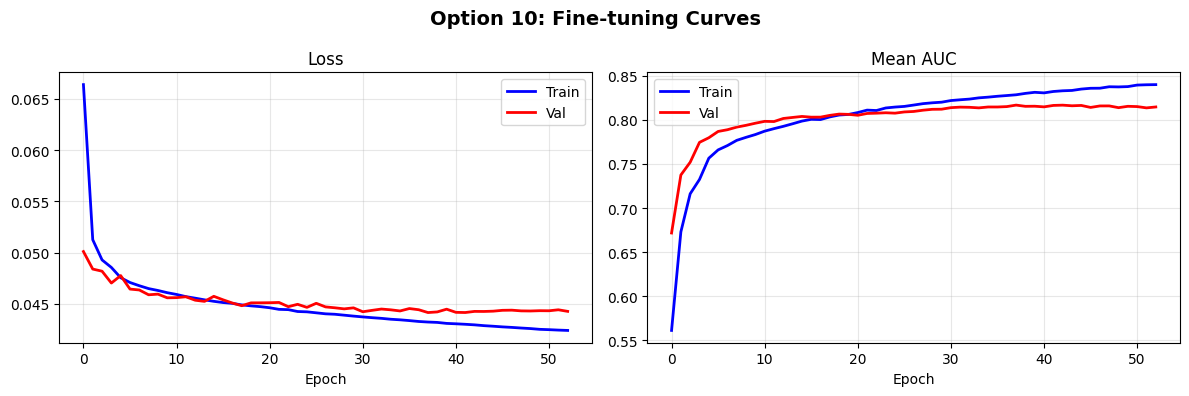

In [60]:
# ============================================
# 📊 Step 13: Plot Fine-tuning Curves
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(finetune_history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(finetune_history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0].set_title('Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(finetune_history['train_auc'], 'b-', label='Train', linewidth=2)
axes[1].plot(finetune_history['val_auc'], 'r-', label='Val', linewidth=2)
axes[1].set_title('Mean AUC', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Option 10: Fine-tuning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OPTION_NAME}_finetune_curves.png', dpi=150, bbox_inches='tight')
plt.show()


📊 TEST SET EVALUATION


Evaluating: 100%|██████████| 18/18 [00:04<00:00,  3.84it/s]



🎯 OPTIMAL THRESHOLDS:
----------------------------------------
Atelectasis         : 0.377
Cardiomegaly        : 0.354
Effusion            : 0.378
Infiltration        : 0.397
Mass                : 0.379
Nodule              : 0.317
Pneumonia           : 0.306
Pneumothorax        : 0.405
Consolidation       : 0.286
Edema               : 0.344
Emphysema           : 0.296
Fibrosis            : 0.297
Pleural_Thickening  : 0.315
Hernia              : 0.232

📊 PER-DISEASE METRICS (TEST SET):
Atelectasis         : AUC=0.7694 | F1=0.3538 | Prec=0.2928 | Rec=0.4469
Cardiomegaly        : AUC=0.9327 | F1=0.5051 | Prec=0.4229 | Rec=0.6271
Effusion            : AUC=0.8697 | F1=0.5563 | Prec=0.4620 | Rec=0.6991
Infiltration        : AUC=0.6828 | F1=0.3788 | Prec=0.3415 | Rec=0.4253
Mass                : AUC=0.8737 | F1=0.4164 | Prec=0.3466 | Rec=0.5214
Nodule              : AUC=0.6596 | F1=0.1853 | Prec=0.1317 | Rec=0.3121
Pneumonia           : AUC=0.7066 | F1=0.0755 | Prec=0.0833 | Rec=0.0690
Pneum

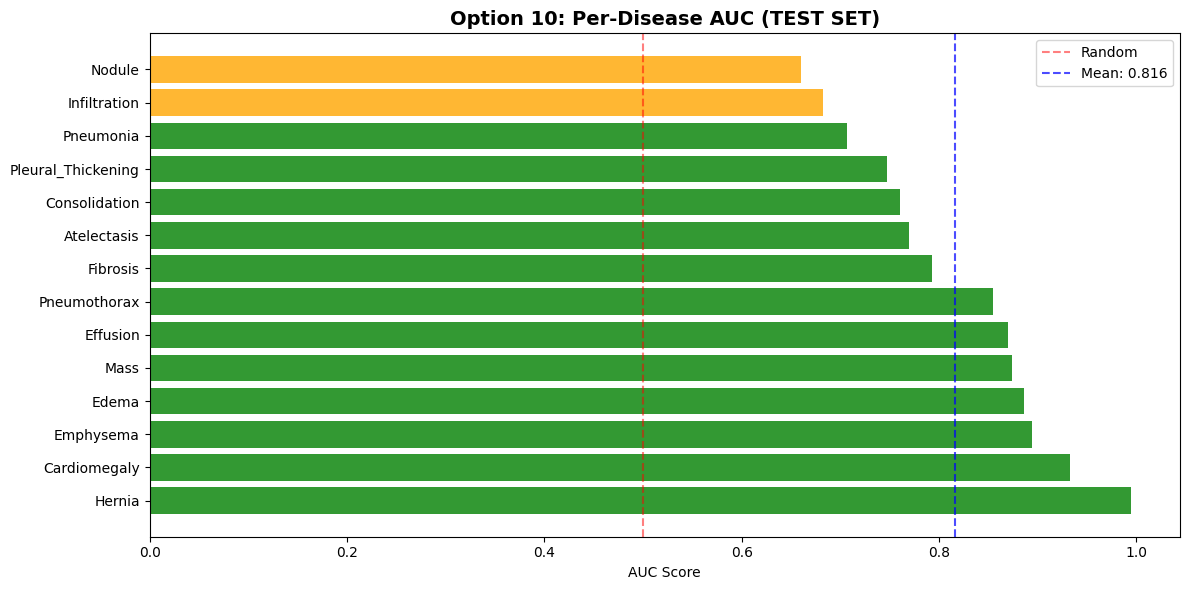

In [61]:
# ============================================
# 📈 Step 14: Final Evaluation on TEST SET
# ============================================

best_model_path = os.path.join(CHECKPOINT_DIR, f'{OPTION_NAME}_best_model.pth')
checkpoint = torch.load(best_model_path, map_location=cfg.device, weights_only=False)
online_encoder.load_state_dict(checkpoint['online_encoder'])
classifier.load_state_dict(checkpoint['classifier'])

online_encoder.eval()
classifier.eval()
online_encoder.set_anatomy_mask(None)

print("=" * 60)
print("📊 TEST SET EVALUATION")
print("=" * 60)

all_preds, all_targets = [], []
with torch.no_grad():
    loader = tqdm(test_loader, desc="Evaluating") if not IN_KAGGLE else test_loader
    for images, targets in loader:
        images = images.to(cfg.device)
        with autocast(enabled=cfg.use_amp):
            tokens = online_encoder(images)
            cls_token = tokens[:, 0, :]
            logits = classifier(cls_token)
        all_preds.append(torch.sigmoid(logits.float()).cpu())
        all_targets.append(targets)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# Optimal thresholds
print("\n🎯 OPTIMAL THRESHOLDS:")
print("-" * 40)
optimal_thresholds = {}
for i, disease in enumerate(DISEASE_CATEGORIES):
    if len(np.unique(all_targets[:, i])) > 1:
        precision, recall, thresholds = precision_recall_curve(all_targets[:, i], all_preds[:, i])
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    else:
        best_threshold = 0.5
    optimal_thresholds[disease] = best_threshold
    print(f"{disease:20s}: {best_threshold:.3f}")

# Per-disease metrics
print("\n📊 PER-DISEASE METRICS (TEST SET):")
print("=" * 60)
auc_scores, f1_scores_list = [], []
for i, disease in enumerate(DISEASE_CATEGORIES):
    if len(np.unique(all_targets[:, i])) > 1:
        auc = roc_auc_score(all_targets[:, i], all_preds[:, i])
        pred_binary = (all_preds[:, i] > optimal_thresholds[disease]).astype(int)
        f1 = f1_score(all_targets[:, i], pred_binary)
        prec = precision_score(all_targets[:, i], pred_binary, zero_division=0)
        rec = recall_score(all_targets[:, i], pred_binary, zero_division=0)
        auc_scores.append(auc)
        f1_scores_list.append(f1)
        print(f"{disease:20s}: AUC={auc:.4f} | F1={f1:.4f} | Prec={prec:.4f} | Rec={rec:.4f}")

mean_auc = np.mean(auc_scores)
mean_f1 = np.mean(f1_scores_list)

print("\n" + "=" * 60)
print(f"🏆 TEST SET RESULTS:")
print(f"   Mean AUC: {mean_auc:.4f}")
print(f"   Mean F1:  {mean_f1:.4f}")
print("=" * 60)

# AUC bar chart
auc_data = list(zip(DISEASE_CATEGORIES, auc_scores))
auc_data.sort(key=lambda x: x[1], reverse=True)
diseases, aucs = zip(*auc_data)

plt.figure(figsize=(12, 6))
colors = ['green' if a >= 0.7 else 'orange' if a >= 0.6 else 'red' for a in aucs]
plt.barh(diseases, aucs, color=colors, alpha=0.8)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random')
plt.axvline(mean_auc, color='blue', linestyle='--', alpha=0.7, label=f'Mean: {mean_auc:.3f}')
plt.xlabel('AUC Score')
plt.title('Option 10: Per-Disease AUC (TEST SET)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OPTION_NAME}_auc_performance.png', dpi=150, bbox_inches='tight')
plt.show()


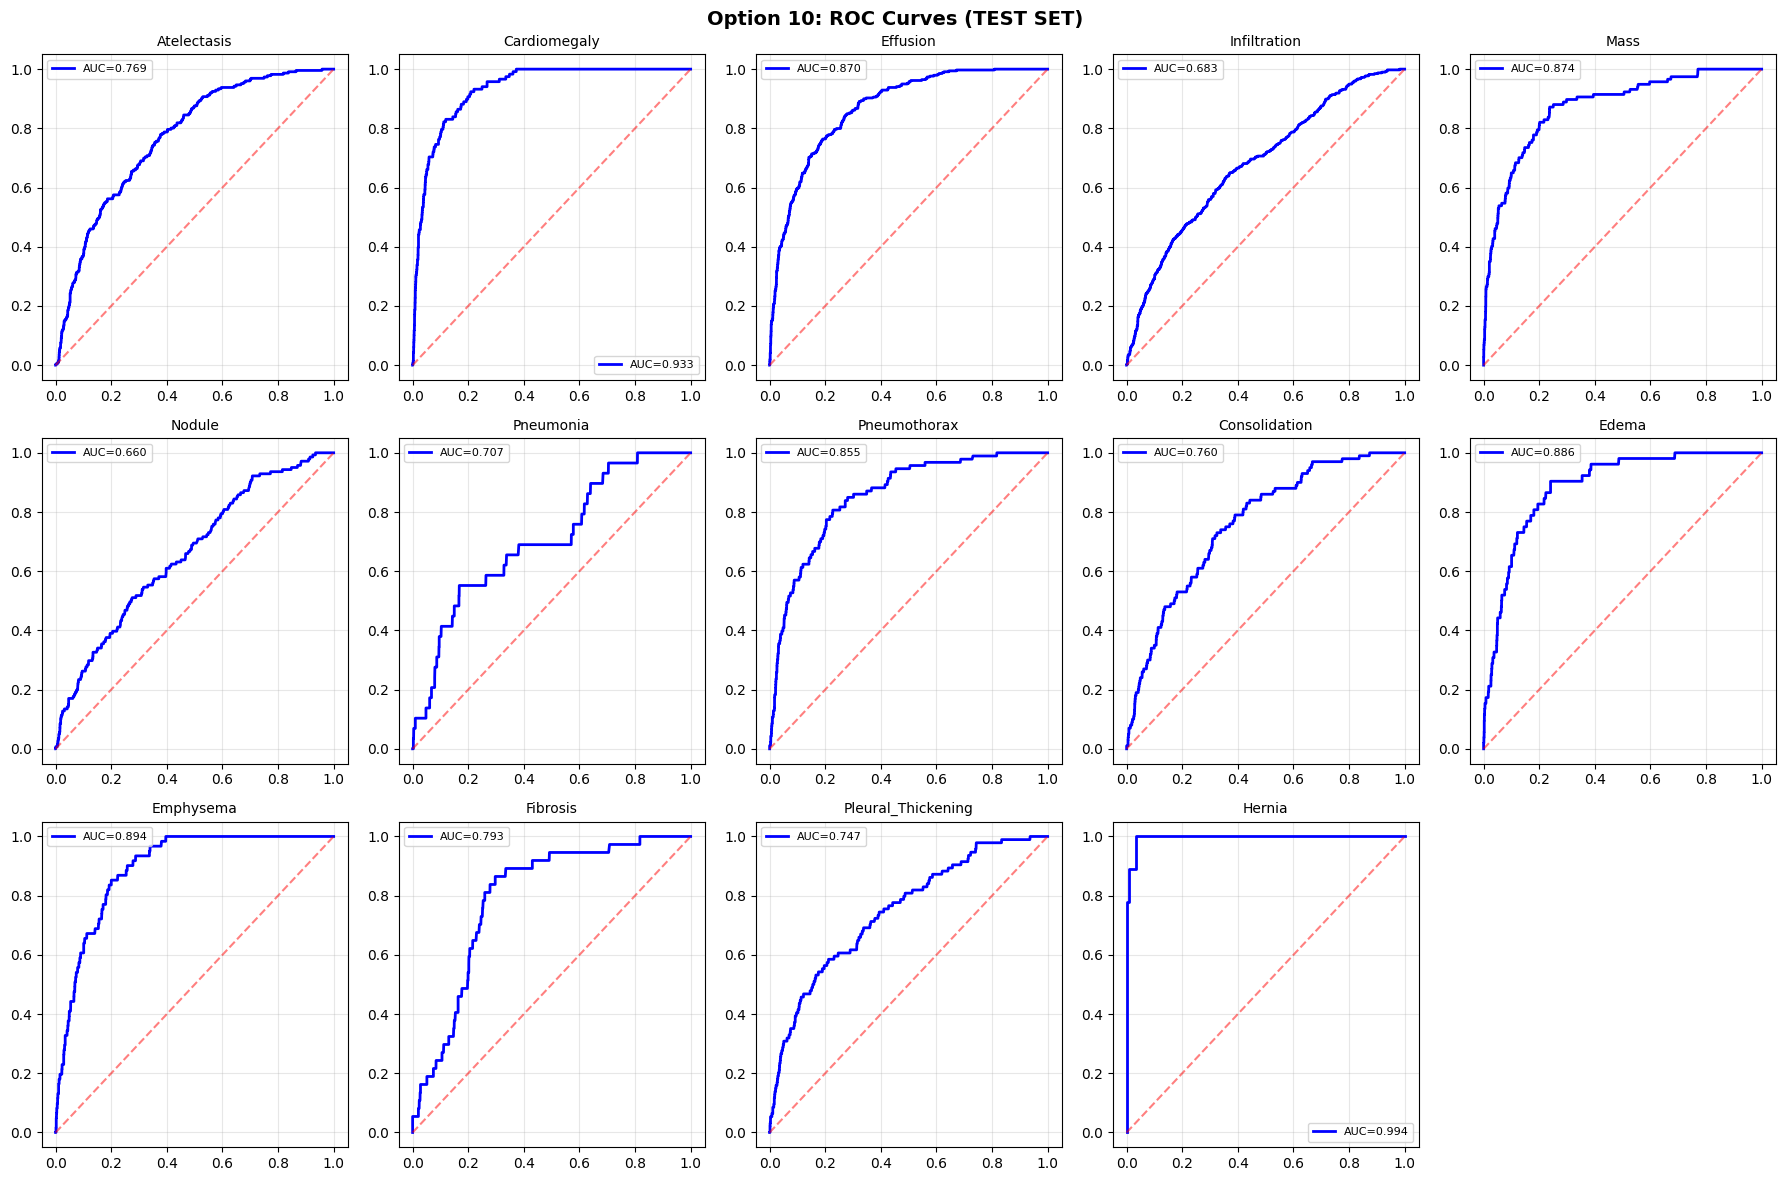

In [62]:
# ============================================
# 📈 Step 15: ROC Curves
# ============================================
from sklearn.metrics import roc_curve, auc

n_diseases = len(DISEASE_CATEGORIES)
n_cols = 5
n_rows = (n_diseases + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, disease in enumerate(DISEASE_CATEGORIES):
    if len(np.unique(all_targets[:, i])) > 1:
        fpr, tpr, _ = roc_curve(all_targets[:, i], all_preds[:, i])
        roc_auc = auc(fpr, tpr)
        axes[i].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC={roc_auc:.3f}')
        axes[i].plot([0, 1], [0, 1], 'r--', alpha=0.5)
        axes[i].set_title(disease, fontsize=10)
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

for j in range(n_diseases, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Option 10: ROC Curves (TEST SET)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OPTION_NAME}_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


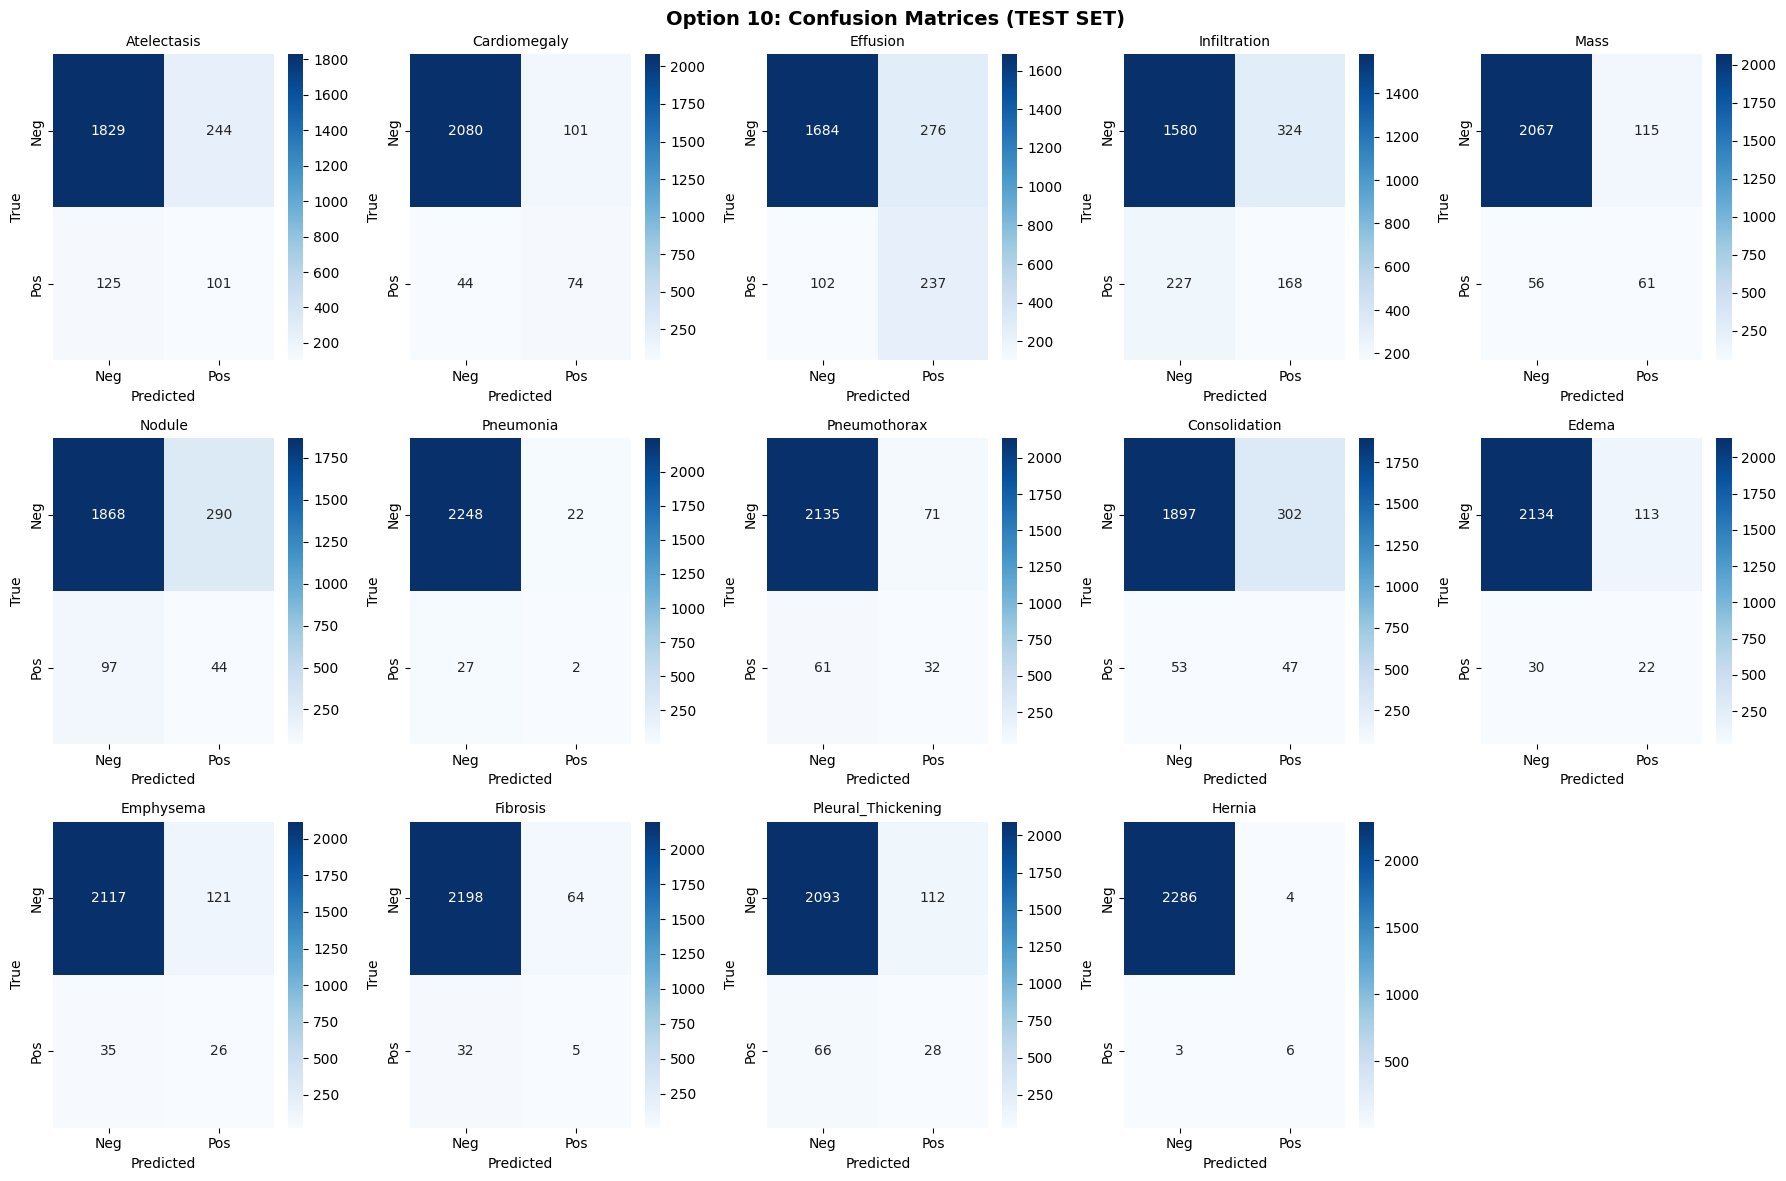

In [63]:
# ============================================
# 🎨 Step 16: Confusion Matrices
# ============================================
from sklearn.metrics import confusion_matrix

test_preds_binary = np.zeros_like(all_preds)
for i, disease in enumerate(DISEASE_CATEGORIES):
    thresh = optimal_thresholds.get(disease, 0.5)
    test_preds_binary[:, i] = (all_preds[:, i] > thresh).astype(int)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, disease in enumerate(DISEASE_CATEGORIES):
    if len(np.unique(all_targets[:, i])) > 1:
        cm = confusion_matrix(all_targets[:, i], test_preds_binary[:, i])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
        axes[i].set_title(disease, fontsize=10)
        axes[i].set_ylabel('True')
        axes[i].set_xlabel('Predicted')

for j in range(n_diseases, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Option 10: Confusion Matrices (TEST SET)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OPTION_NAME}_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


🧠 Generating attention visualizations...

Sample 1: 00000097_000.png


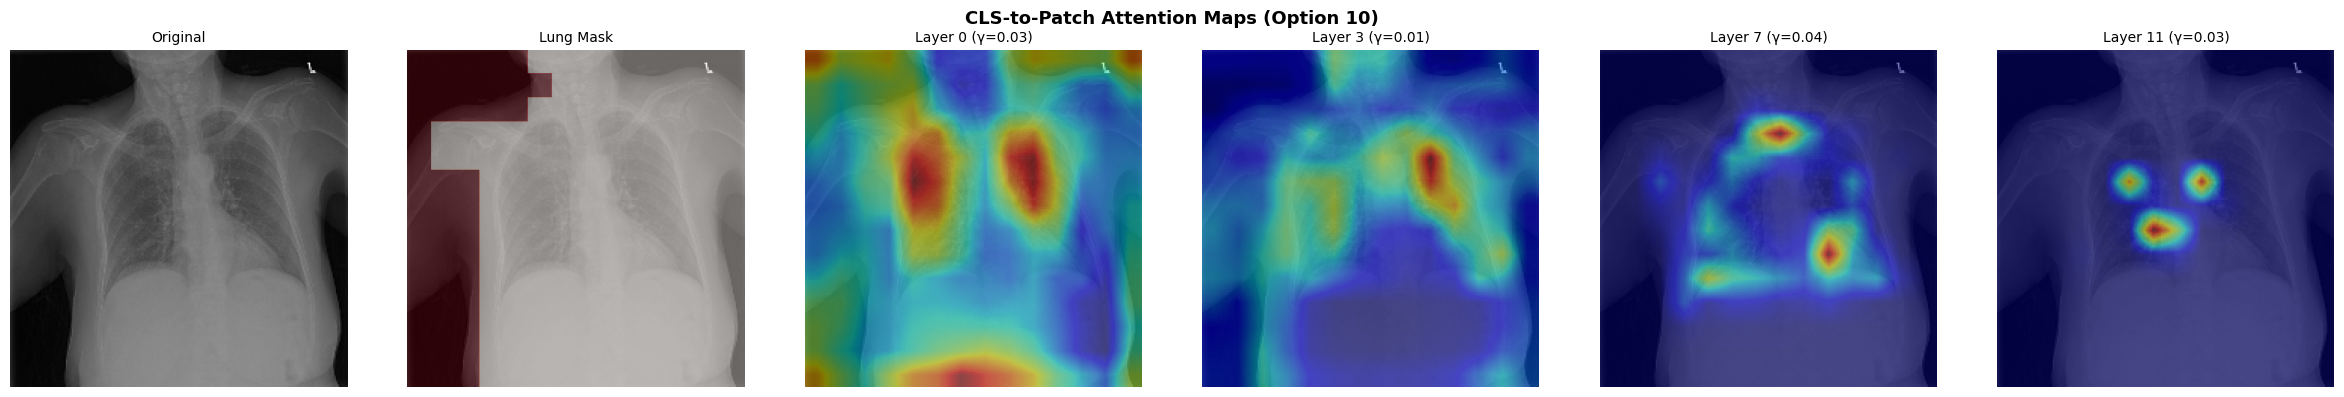


Sample 2: 00000211_000.png


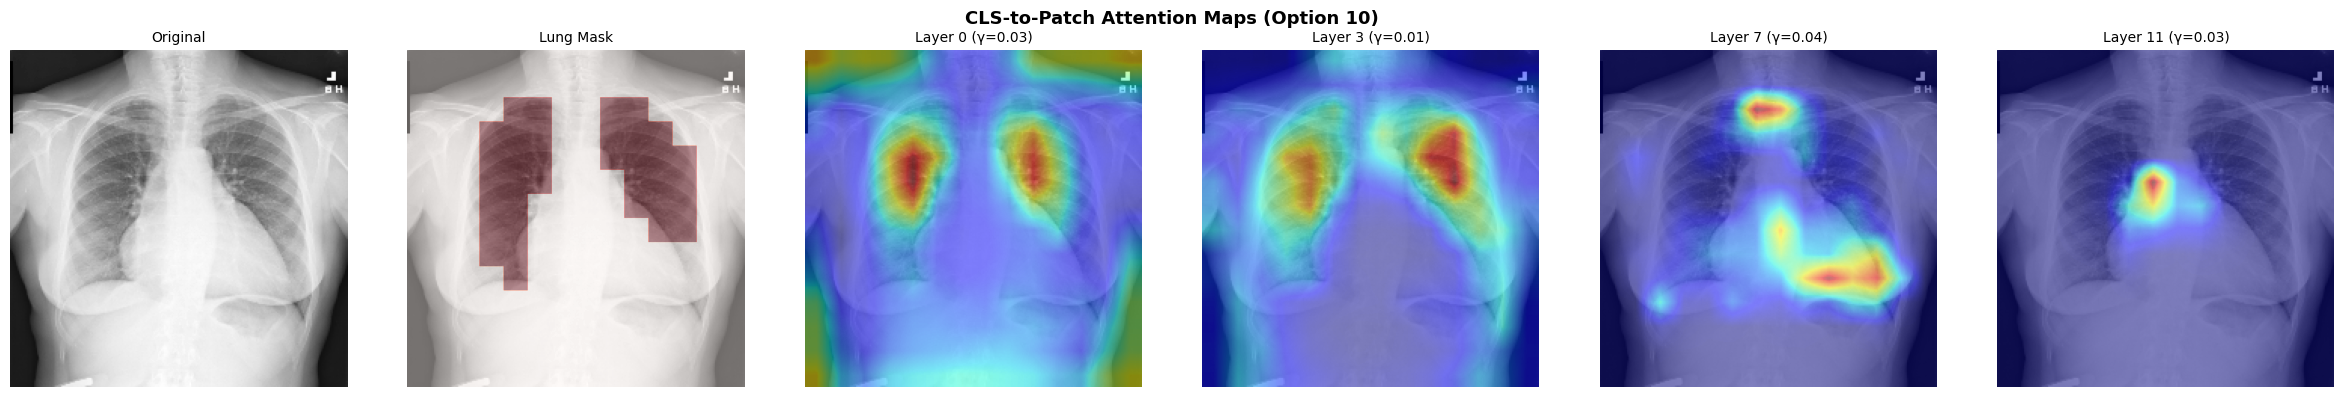


Sample 3: 00000211_001.png


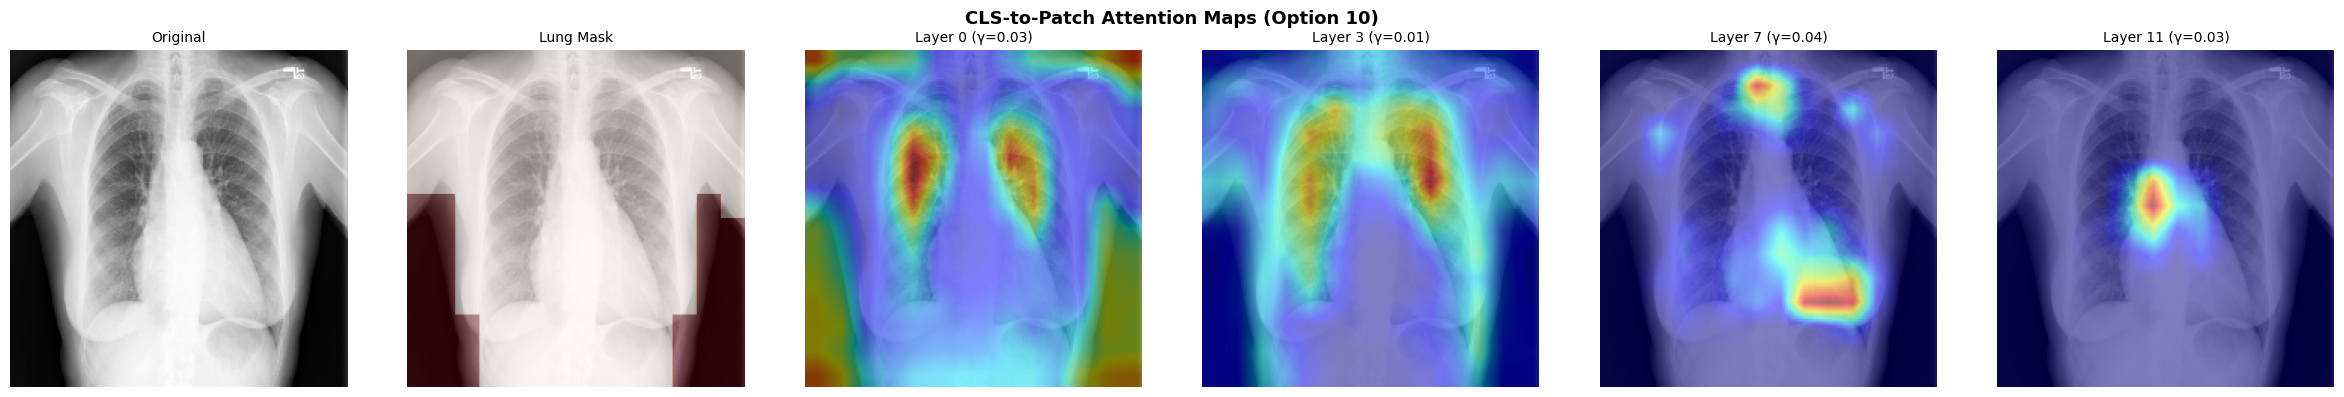

✅ Attention visualizations complete


In [25]:
# ============================================
# 🧠 Step 17: Attention Map Interpretability (P4)
# ============================================
# Visualize how the learned attention aligns with lung anatomy.
# This provides qualitative evidence that the model learns to focus on
# diagnostically relevant regions.

def visualize_attention(encoder, image_path, mask_path=None, layer_indices=None,
                        img_size=224, patch_size=16, device='cuda'):
    """
    Visualize CLS-to-patch attention maps for a given image.
    
    Args:
        encoder:       Trained ViTEncoder (eval mode)
        image_path:    Path to a chest X-ray image
        mask_path:     Optional path to the lung patch mask (.npy)
        layer_indices: Which layers to visualize (default: [0, 3, 7, 11])
        img_size:      Image size
        patch_size:    Patch size
        device:        Device
    """
    if layer_indices is None:
        layer_indices = [0, 3, 7, 11]  # early, mid-early, mid-late, final
    
    # Load and preprocess image
    img_np = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_np = cv2.resize(img_np, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    img_display = img_np.copy()
    img_np = img_np.astype(np.float32) / 255.0
    img_tensor = to_3ch_imagenet(img_np).unsqueeze(0).to(device)
    
    # Load mask if available
    if mask_path and os.path.exists(mask_path):
        patch_mask = np.load(mask_path)
        mask_tensor = torch.from_numpy(patch_mask).unsqueeze(0).to(device)
        encoder.set_anatomy_mask(mask_tensor)
    else:
        encoder.set_anatomy_mask(None)
        patch_mask = None
    
    # Forward pass
    encoder.eval()
    with torch.no_grad():
        tokens = encoder(img_tensor)
    
    # Get attention maps
    attn_maps = encoder.get_attention_maps()
    
    n_patches_side = img_size // patch_size  # 14
    
    n_cols = len(layer_indices) + 2  # original + mask + layers
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    
    # Original image
    axes[0].imshow(img_display, cmap='gray')
    axes[0].set_title('Original', fontsize=10)
    axes[0].axis('off')
    
    # Lung mask
    if patch_mask is not None:
        mask_2d = patch_mask.reshape(n_patches_side, n_patches_side)
        mask_upscaled = cv2.resize(mask_2d, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
        axes[1].imshow(img_display, cmap='gray')
        axes[1].imshow(mask_upscaled, cmap='Reds', alpha=0.4)
        axes[1].set_title('Lung Mask', fontsize=10)
    else:
        axes[1].imshow(img_display, cmap='gray')
        axes[1].set_title('No Mask', fontsize=10)
    axes[1].axis('off')
    
    # Attention maps per layer
    for idx, layer_i in enumerate(layer_indices):
        if layer_i < len(attn_maps) and attn_maps[layer_i] is not None:
            # Average over heads, take CLS-to-patch attention
            attn = attn_maps[layer_i][0]  # (H, T, T) — first image in batch
            cls_attn = attn[:, 0, 1:].mean(dim=0).cpu().numpy()  # (N,) avg over heads
            attn_2d = cls_attn.reshape(n_patches_side, n_patches_side)
            attn_upscaled = cv2.resize(attn_2d, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            
            axes[idx + 2].imshow(img_display, cmap='gray')
            axes[idx + 2].imshow(attn_upscaled, cmap='jet', alpha=0.5)
            gamma_val = torch.sigmoid(encoder.gamma_logits[layer_i]).item()
            axes[idx + 2].set_title(f'Layer {layer_i} (γ={gamma_val:.2f})', fontsize=10)
        else:
            axes[idx + 2].set_title(f'Layer {layer_i} N/A', fontsize=10)
        axes[idx + 2].axis('off')
    
    plt.suptitle('CLS-to-Patch Attention Maps (Option 10)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OPTION_NAME}_attention_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    encoder.set_anatomy_mask(None)  # Reset


# Visualize attention for a few test samples
print("🧠 Generating attention visualizations...")
n_samples = min(3, len(test_df))
for sample_idx in range(n_samples):
    row = test_df.iloc[sample_idx]
    img_path = row['Image Path']
    img_name = row['Image Index']
    mask_name = img_name.replace(".jpg", "").replace(".png", "").replace('/', '_')
    mask_path = os.path.join(NIH_MASK_DIR, f"{mask_name}.npy")
    
    print(f"\nSample {sample_idx+1}: {img_name}")
    visualize_attention(online_encoder, img_path, mask_path, device=cfg.device)

print("✅ Attention visualizations complete")


In [26]:
# ============================================
# 🔬 Step 18: Ablation Study Infrastructure (P3)
# ============================================
# This cell defines the ablation framework. Each ablation disables one component
# and re-runs SSL pretraining + fine-tuning to measure its contribution.
#
# ABLATION MODES:
#   "full"              — All components enabled (baseline for ablation)
#   "no_attn_align"     — Remove attention alignment loss
#   "no_recon"          — Remove reconstruction loss
#   "no_contrastive"    — Remove contrastive loss
#   "no_learnable_gamma"— Fixed gamma (no learnable attention bias)
#   "no_progressive_mask"— Fixed mask ratio (no curriculum)
#   "no_cross_domain"   — Remove cross-domain alignment
#   "no_layer_selective" — Uniform layer weighting (no exponential)
#
# NOTE: Running all ablations takes significant compute.
# Each ablation is a separate run. Adjust pretrain/finetune epochs as needed.

ABLATION_CONFIGS = {
    "full": {
        "lambda_attn": 0.05,
        "lambda_contrastive": 1.0,
        "lambda_cross_domain": 0.1,
        "use_progressive_mask": True,
        "use_learnable_gamma": True,
        "use_layer_selective": True,
        "use_recon": True,
    },
    "no_attn_align": {
        "lambda_attn": 0.0,
        "lambda_contrastive": 1.0,
        "lambda_cross_domain": 0.1,
        "use_progressive_mask": True,
        "use_learnable_gamma": False,  # No gamma if no attn loss
        "use_layer_selective": False,
        "use_recon": True,
    },
    "no_recon": {
        "lambda_attn": 0.05,
        "lambda_contrastive": 1.0,
        "lambda_cross_domain": 0.1,
        "use_progressive_mask": False,  # No masking if no recon
        "use_learnable_gamma": True,
        "use_layer_selective": True,
        "use_recon": False,
    },
    "no_contrastive": {
        "lambda_attn": 0.05,
        "lambda_contrastive": 0.0,
        "lambda_cross_domain": 0.0,  # No cross-domain without contrastive
        "use_progressive_mask": True,
        "use_learnable_gamma": True,
        "use_layer_selective": True,
        "use_recon": True,
    },
    "no_learnable_gamma": {
        "lambda_attn": 0.05,
        "lambda_contrastive": 1.0,
        "lambda_cross_domain": 0.1,
        "use_progressive_mask": True,
        "use_learnable_gamma": False,
        "use_layer_selective": True,
        "use_recon": True,
    },
    "no_progressive_mask": {
        "lambda_attn": 0.05,
        "lambda_contrastive": 1.0,
        "lambda_cross_domain": 0.1,
        "use_progressive_mask": False,  # Fixed 0.5
        "use_learnable_gamma": True,
        "use_layer_selective": True,
        "use_recon": True,
    },
    "no_cross_domain": {
        "lambda_attn": 0.05,
        "lambda_contrastive": 1.0,
        "lambda_cross_domain": 0.0,
        "use_progressive_mask": True,
        "use_learnable_gamma": True,
        "use_layer_selective": True,
        "use_recon": True,
    },
    "no_layer_selective": {
        "lambda_attn": 0.05,
        "lambda_contrastive": 1.0,
        "lambda_cross_domain": 0.1,
        "use_progressive_mask": True,
        "use_learnable_gamma": True,
        "use_layer_selective": False,  # tau -> infinity (uniform)
        "use_recon": True,
    },
}

def run_ablation_summary():
    """Print ablation configuration table."""
    print("=" * 80)
    print("🔬 ABLATION STUDY CONFIGURATIONS")
    print("=" * 80)
    header = f"{'Mode':<22} {'Attn':>5} {'Recon':>5} {'Cont':>5} {'XDom':>5} {'ProgM':>5} {'LearnG':>6} {'LayerS':>6}"
    print(header)
    print("-" * 80)
    for mode, cfg_ab in ABLATION_CONFIGS.items():
        row = (f"{mode:<22} "
               f"{cfg_ab['lambda_attn']:>5.2f} "
               f"{'✓' if cfg_ab['use_recon'] else '✗':>5} "
               f"{cfg_ab['lambda_contrastive']:>5.1f} "
               f"{cfg_ab['lambda_cross_domain']:>5.2f} "
               f"{'✓' if cfg_ab['use_progressive_mask'] else '✗':>5} "
               f"{'✓' if cfg_ab['use_learnable_gamma'] else '✗':>6} "
               f"{'✓' if cfg_ab['use_layer_selective'] else '✗':>6}")
        print(row)
    print("=" * 80)
    print("\n⚠️ To run ablations, modify the SSL training loop above to use these configs.")
    print("   Each ablation should be run separately and results recorded in a table.")
    print("   Recommended: reduce pretrain_epochs to 30 for ablation sweeps.")

run_ablation_summary()


🔬 ABLATION STUDY CONFIGURATIONS
Mode                    Attn Recon  Cont  XDom ProgM LearnG LayerS
--------------------------------------------------------------------------------
full                    0.05     ✓   1.0  0.10     ✓      ✓      ✓
no_attn_align           0.00     ✓   1.0  0.10     ✓      ✗      ✗
no_recon                0.05     ✗   1.0  0.10     ✗      ✓      ✓
no_contrastive          0.05     ✓   0.0  0.00     ✓      ✓      ✓
no_learnable_gamma      0.05     ✓   1.0  0.10     ✓      ✗      ✓
no_progressive_mask     0.05     ✓   1.0  0.10     ✗      ✓      ✓
no_cross_domain         0.05     ✓   1.0  0.00     ✓      ✓      ✓
no_layer_selective      0.05     ✓   1.0  0.10     ✓      ✓      ✗

⚠️ To run ablations, modify the SSL training loop above to use these configs.
   Each ablation should be run separately and results recorded in a table.
   Recommended: reduce pretrain_epochs to 30 for ablation sweeps.


In [27]:
# ============================================
# 📊 Step 19: Low-Label Regime Experiment (P3)
# ============================================
# Evaluates the pretrained encoder with different fractions of labeled data.
# SSL methods should shine in low-label settings — this demonstrates practical value.
#
# Uses the already-trained SSL encoder and fine-tunes with varying label fractions.

def run_low_label_experiment(encoder_state_dict, label_fractions=None,
                             ft_epochs=50, n_seeds=1):
    """
    Run fine-tuning with different fractions of labeled data.
    
    Args:
        encoder_state_dict: State dict of the SSL-pretrained encoder
        label_fractions:    List of fractions to evaluate
        ft_epochs:          Number of fine-tuning epochs per fraction
        n_seeds:            Number of seeds per fraction (for mean±std)
    
    Returns:
        Dictionary mapping fraction -> list of AUC scores (one per seed)
    """
    if label_fractions is None:
        label_fractions = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
    
    results = {}
    
    for frac in label_fractions:
        frac_aucs = []
        
        for seed in range(n_seeds):
            print(f"\n{'='*50}")
            print(f"🧪 Label fraction: {frac*100:.1f}% | Seed: {seed}")
            print(f"{'='*50}")
            
            # Create subsampled training set
            rng = np.random.RandomState(42 + seed)
            n_patients = max(1, int(len(train_patients) * frac))
            patient_idx = rng.choice(len(train_patients), size=n_patients, replace=False)
            subset_patients = train_patients[patient_idx]
            subset_df = train_df[train_df['Patient ID'].isin(subset_patients)].reset_index(drop=True)
            
            print(f"   Patients: {n_patients:,} | Images: {len(subset_df):,}")
            
            # Create fresh encoder + classifier
            enc = ViTEncoder(
                img_size=cfg.img_size, patch_size=cfg.patch_size, in_chans=3,
                embed_dim=cfg.embed_dim, depth=cfg.depth,
                num_heads=cfg.num_heads, mlp_ratio=cfg.mlp_ratio,
                use_pretrained=False, gamma_logit_init=cfg._gamma_logit_init
            ).to(cfg.device)
            enc.load_state_dict(encoder_state_dict)
            enc.set_anatomy_mask(None)
            
            cls = Classifier(cfg.embed_dim, len(DISEASE_CATEGORIES), dropout=cfg.dropout_rate).to(cfg.device)
            
            # Create data loader
            subset_dataset = ClassificationDataset(subset_df, DISEASE_CATEGORIES, cfg.img_size, is_training=True)
            subset_loader = DataLoader(subset_dataset, batch_size=cfg.batch_size, shuffle=True,
                                       num_workers=4, pin_memory=True)
            
            # Fine-tune
            opt = torch.optim.AdamW([
                {'params': enc.parameters(), 'lr': cfg.lr_finetune * cfg.backbone_lr_multiplier},
                {'params': cls.parameters(), 'lr': cfg.lr_finetune},
            ], weight_decay=cfg.weight_decay_finetune)
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ft_epochs, eta_min=1e-7)
            criterion = FocalLossWithSmoothing(alpha=cfg.focal_alpha, gamma=cfg.focal_gamma)
            ll_scaler = GradScaler(enabled=cfg.use_amp)
            
            best_auc = 0.0
            for ep in range(1, ft_epochs + 1):
                enc.train(); cls.train()
                for imgs, tgts in subset_loader:
                    imgs, tgts = imgs.to(cfg.device), tgts.to(cfg.device)
                    with autocast(enabled=cfg.use_amp):
                        tokens = enc(imgs)
                        logits = cls(tokens[:, 0, :])
                        loss = criterion(logits, tgts)
                    opt.zero_grad()
                    ll_scaler.scale(loss).backward()
                    ll_scaler.step(opt)
                    ll_scaler.update()
                sched.step()
                
                # Validate
                enc.eval(); cls.eval()
                vp, vt = [], []
                with torch.no_grad():
                    for imgs, tgts in val_loader:
                        imgs = imgs.to(cfg.device)
                        with autocast(enabled=cfg.use_amp):
                            logits = cls(enc(imgs)[:, 0, :])
                        vp.append(torch.sigmoid(logits.float()).cpu())
                        vt.append(tgts)
                vp = torch.cat(vp).numpy(); vt = torch.cat(vt).numpy()
                val_auc = np.mean([roc_auc_score(vt[:, i], vp[:, i])
                                   for i in range(len(DISEASE_CATEGORIES))
                                   if len(np.unique(vt[:, i])) > 1])
                if val_auc > best_auc:
                    best_auc = val_auc
            
            frac_aucs.append(best_auc)
            print(f"   Best Val AUC: {best_auc:.4f}")
            
            del enc, cls, opt  # Free memory
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        results[frac] = frac_aucs
        mean_auc = np.mean(frac_aucs)
        std_auc = np.std(frac_aucs) if len(frac_aucs) > 1 else 0.0
        print(f"\n📊 Fraction {frac*100:.1f}%: AUC = {mean_auc:.4f} ± {std_auc:.4f}")
    
    return results


# ── Print instructions ──
print("=" * 60)
print("📊 LOW-LABEL REGIME EXPERIMENT")
print("=" * 60)
print("To run: call run_low_label_experiment(state_dict)")
print("Example:")
print("  results = run_low_label_experiment(")
print("      online_encoder.state_dict(),")
print("      label_fractions=[0.01, 0.05, 0.1, 0.5, 1.0],")
print("      ft_epochs=30, n_seeds=3")
print("  )")
print("\n⚠️ This takes significant compute. Reduce ft_epochs for quick tests.")

# Uncomment the following to run:
# low_label_results = run_low_label_experiment(
#     online_encoder.state_dict(),
#     label_fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0],
#     ft_epochs=30,
#     n_seeds=3
# )


📊 LOW-LABEL REGIME EXPERIMENT
To run: call run_low_label_experiment(state_dict)
Example:
  results = run_low_label_experiment(
      online_encoder.state_dict(),
      label_fractions=[0.01, 0.05, 0.1, 0.5, 1.0],
      ft_epochs=30, n_seeds=3
  )

⚠️ This takes significant compute. Reduce ft_epochs for quick tests.


In [28]:
# ============================================
# 🎲 Step 20: Multi-Seed Run Infrastructure (P3)
# ============================================
# For statistical significance in the paper, run the full pipeline
# with multiple random seeds and report mean ± std.

def run_multi_seed_evaluation(encoder_state_dict, seeds=None, ft_epochs=50):
    """
    Run fine-tuning from the same pretrained encoder with multiple seeds.
    Reports mean ± std AUC across seeds for statistical significance.
    
    Args:
        encoder_state_dict: Pretrained SSL encoder weights
        seeds:              List of random seeds
        ft_epochs:          Fine-tuning epochs per seed
    
    Returns:
        per_seed_results: dict[seed] -> (val_auc, test_auc, per_disease_aucs)
    """
    if seeds is None:
        seeds = [42, 123, 456, 789, 1024]
    
    all_val_aucs = []
    all_test_aucs = []
    all_per_disease = {d: [] for d in DISEASE_CATEGORIES}
    
    for seed in seeds:
        print(f"\n{'='*50}")
        print(f"🎲 Seed: {seed}")
        print(f"{'='*50}")
        
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        
        enc = ViTEncoder(
            img_size=cfg.img_size, patch_size=cfg.patch_size, in_chans=3,
            embed_dim=cfg.embed_dim, depth=cfg.depth,
            num_heads=cfg.num_heads, mlp_ratio=cfg.mlp_ratio,
            use_pretrained=False, gamma_logit_init=cfg._gamma_logit_init
        ).to(cfg.device)
        enc.load_state_dict(encoder_state_dict)
        enc.set_anatomy_mask(None)
        
        cls = Classifier(cfg.embed_dim, len(DISEASE_CATEGORIES), dropout=cfg.dropout_rate).to(cfg.device)
        
        opt = torch.optim.AdamW([
            {'params': enc.parameters(), 'lr': cfg.lr_finetune * cfg.backbone_lr_multiplier},
            {'params': cls.parameters(), 'lr': cfg.lr_finetune},
        ], weight_decay=cfg.weight_decay_finetune)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ft_epochs, eta_min=1e-7)
        criterion = FocalLossWithSmoothing(alpha=cfg.focal_alpha, gamma=cfg.focal_gamma)
        ms_scaler = GradScaler(enabled=cfg.use_amp)
        
        best_val_auc = 0.0
        best_state = None
        
        for ep in range(1, ft_epochs + 1):
            enc.train(); cls.train()
            for imgs, tgts in train_loader:
                imgs, tgts = imgs.to(cfg.device), tgts.to(cfg.device)
                with autocast(enabled=cfg.use_amp):
                    logits = cls(enc(imgs)[:, 0, :])
                    loss = criterion(logits, tgts)
                opt.zero_grad()
                ms_scaler.scale(loss).backward()
                ms_scaler.step(opt)
                ms_scaler.update()
            sched.step()
            
            enc.eval(); cls.eval()
            vp, vt = [], []
            with torch.no_grad():
                for imgs, tgts in val_loader:
                    imgs = imgs.to(cfg.device)
                    with autocast(enabled=cfg.use_amp):
                        logits = cls(enc(imgs)[:, 0, :])
                    vp.append(torch.sigmoid(logits.float()).cpu())
                    vt.append(tgts)
            vp = torch.cat(vp).numpy(); vt = torch.cat(vt).numpy()
            val_auc = np.mean([roc_auc_score(vt[:, i], vp[:, i])
                               for i in range(len(DISEASE_CATEGORIES))
                               if len(np.unique(vt[:, i])) > 1])
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_state = {'enc': copy.deepcopy(enc.state_dict()),
                              'cls': copy.deepcopy(cls.state_dict())}
        
        # Evaluate on test set with best model
        enc.load_state_dict(best_state['enc'])
        cls.load_state_dict(best_state['cls'])
        enc.eval(); cls.eval()
        tp, tt = [], []
        with torch.no_grad():
            for imgs, tgts in test_loader:
                imgs = imgs.to(cfg.device)
                with autocast(enabled=cfg.use_amp):
                    logits = cls(enc(imgs)[:, 0, :])
                tp.append(torch.sigmoid(logits.float()).cpu())
                tt.append(tgts)
        tp = torch.cat(tp).numpy(); tt = torch.cat(tt).numpy()
        
        test_aucs_per_disease = {}
        for i, d in enumerate(DISEASE_CATEGORIES):
            if len(np.unique(tt[:, i])) > 1:
                auc_val = roc_auc_score(tt[:, i], tp[:, i])
                test_aucs_per_disease[d] = auc_val
                all_per_disease[d].append(auc_val)
        
        test_auc = np.mean(list(test_aucs_per_disease.values()))
        all_val_aucs.append(best_val_auc)
        all_test_aucs.append(test_auc)
        
        print(f"   Val AUC: {best_val_auc:.4f} | Test AUC: {test_auc:.4f}")
        
        del enc, cls, opt
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Summary
    print(f"\n{'='*60}")
    print(f"🎲 MULTI-SEED RESULTS ({len(seeds)} seeds)")
    print(f"{'='*60}")
    print(f"   Val AUC:  {np.mean(all_val_aucs):.4f} ± {np.std(all_val_aucs):.4f}")
    print(f"   Test AUC: {np.mean(all_test_aucs):.4f} ± {np.std(all_test_aucs):.4f}")
    print(f"\n   Per-Disease Test AUC (mean ± std):")
    for d in DISEASE_CATEGORIES:
        if len(all_per_disease[d]) > 0:
            print(f"   {d:20s}: {np.mean(all_per_disease[d]):.4f} ± {np.std(all_per_disease[d]):.4f}")
    
    return {
        'val_aucs': all_val_aucs,
        'test_aucs': all_test_aucs,
        'per_disease': all_per_disease
    }


print("=" * 60)
print("🎲 MULTI-SEED EVALUATION")
print("=" * 60)
print("To run: call run_multi_seed_evaluation(state_dict)")
print("Example:")
print("  results = run_multi_seed_evaluation(")
print("      online_encoder.state_dict(),")
print("      seeds=[42, 123, 456, 789, 1024],")
print("      ft_epochs=50")
print("  )")
print("\n⚠️ Running 5 seeds × 50 epochs each. Budget ~5x single run time.")

# Uncomment to run:
# multi_seed_results = run_multi_seed_evaluation(
#     online_encoder.state_dict(),
#     seeds=[42, 123, 456, 789, 1024],
#     ft_epochs=50
# )


🎲 MULTI-SEED EVALUATION
To run: call run_multi_seed_evaluation(state_dict)
Example:
  results = run_multi_seed_evaluation(
      online_encoder.state_dict(),
      seeds=[42, 123, 456, 789, 1024],
      ft_epochs=50
  )

⚠️ Running 5 seeds × 50 epochs each. Budget ~5x single run time.


In [29]:
# ============================================
# 📝 Step 21: Summary
# ============================================

print("\n" + "=" * 70)
print("📝 OPTION 10: ENHANCED ANATOMY-CONSTRAINED MASKED ATTENTION SSL")
print("=" * 70)
print(f"\nMethod: ViT-Small + Momentum Teacher + Learnable Anatomy Attention Bias")
print(f"        + Progressive Mask Curriculum + Layer-Selective Alignment")
print(f"        + Cross-Dataset Domain Alignment + AMP Training")
print(f"\nDatasets: NIH Chest X-ray 14 + CheXpert (multi-dataset SSL)")
print(f"Training: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}")
print(f"\nPretraining epochs: {cfg.pretrain_epochs}")
print(f"Fine-tuning epochs: {cfg.finetune_epochs}")

print(f"\n🔧 Core Components:")
print(f"   ✅ ViT-Small encoder (embed_dim={cfg.embed_dim}, depth={cfg.depth}, heads={cfg.num_heads})")
print(f"   ✅ Momentum teacher (EMA m={cfg.momentum})")
print(f"   ✅ ImageNet pretrained backbone")

print(f"\n🆕 Novel Contributions (vs Option 8):")
print(f"   ✅ [P0] Bug fixes: closure, proj_head optimizer, correct naming")
print(f"   ✅ [P1] Learnable per-layer γ attention bias (init={cfg.gamma_init})")
gamma_vals = online_encoder.get_gamma_values()
print(f"         Learned γ: {[f'{g:.3f}' for g in gamma_vals]}")
print(f"   ✅ [P1] Progressive mask curriculum ({cfg.mask_ratio_min}→{cfg.mask_ratio_max})")
print(f"   ✅ [P1] Layer-selective attention alignment (τ={cfg.attn_layer_tau})")
print(f"   ✅ [P2] AMP mixed-precision training")
print(f"   ✅ [P2] Fixed attention hook closure bug (correct per-block QKV)")
print(f"   ✅ [P3] Ablation study infrastructure (8 configurations)")
print(f"   ✅ [P3] Low-label regime evaluation framework")
print(f"   ✅ [P3] Multi-seed statistical significance framework")
print(f"   ✅ [P4] Cross-dataset contrastive alignment (λ={cfg.lambda_cross_domain})")
print(f"   ✅ [P4] Attention map interpretability visualization")

print(f"\n🔧 Standard Components:")
print(f"   ✅ Lung-aware masking (anatomy-constrained)")
print(f"   ✅ Attention alignment loss (cross-entropy with soft lung prior)")
print(f"   ✅ NT-Xent contrastive loss")
print(f"   ✅ Masked reconstruction loss (MSE on teacher targets)")
print(f"   ✅ Patient-level data splits")
print(f"   ✅ Focal Loss for class imbalance")
print(f"   ✅ Differential learning rates")
print(f"   ✅ Per-disease optimal thresholds")

print(f"\n🏆 TEST SET Mean AUC: {mean_auc:.4f}")
print(f"🏆 TEST SET Mean F1:  {mean_f1:.4f}")

print(f"\nFiles saved:")
print(f"  - {OPTION_NAME}_ssl_pretrained.pth")
print(f"  - {OPTION_NAME}_best_model.pth")
print(f"  - {OPTION_NAME}_ssl_curves.png")
print(f"  - {OPTION_NAME}_gamma_per_layer.png")
print(f"  - {OPTION_NAME}_finetune_curves.png")
print(f"  - {OPTION_NAME}_auc_performance.png")
print(f"  - {OPTION_NAME}_roc_curves.png")
print(f"  - {OPTION_NAME}_confusion_matrices.png")
print(f"  - {OPTION_NAME}_attention_visualization.png")
print("=" * 70)



📝 OPTION 10: ENHANCED ANATOMY-CONSTRAINED MASKED ATTENTION SSL

Method: ViT-Small + Momentum Teacher + Learnable Anatomy Attention Bias
        + Progressive Mask Curriculum + Layer-Selective Alignment
        + Cross-Dataset Domain Alignment + AMP Training

Datasets: NIH Chest X-ray 14 + CheXpert (multi-dataset SSL)
Training: 103,634 | Validation: 6,187 | Test: 2,299

Pretraining epochs: 100
Fine-tuning epochs: 100

🔧 Core Components:
   ✅ ViT-Small encoder (embed_dim=384, depth=12, heads=6)
   ✅ Momentum teacher (EMA m=0.996)
   ✅ ImageNet pretrained backbone

🆕 Novel Contributions (vs Option 8):
   ✅ [P0] Bug fixes: closure, proj_head optimizer, correct naming
   ✅ [P1] Learnable per-layer γ attention bias (init=0.6)
         Learned γ: ['0.034', '0.026', '0.029', '0.013', '0.020', '0.789', '0.015', '0.039', '0.024', '0.025', '0.023', '0.028']
   ✅ [P1] Progressive mask curriculum (0.3→0.75)
   ✅ [P1] Layer-selective attention alignment (τ=2.0)
   ✅ [P2] AMP mixed-precision trainin